# Developmental Project - S-A expansion
- S-A axis expansion computation 
- Outlier removal
- Plotting (Figs 3 & 4)

## Load Packages

In [1]:
# General
import os
import sys
import numpy as np
import pandas as pd
import csv
import math
from math import isnan
import statistics
import pickle
from collections import Counter
import itertools

# Computing / Analyses
import scipy.io  # loadmat
import hdf5storage  # hdf5storage to write in HDF5 format (instead of .mat file, when matrix is too large) -> hdf5storage.write() hdf5storage.read()
import fnmatch # for comparing patterns of syntax
from scipy import stats
import sklearn 
from brainstat.stats.terms import FixedEffect
from brainstat.stats.SLM import SLM
from statsmodels.stats.multitest import fdrcorrection # does not yield exactly the same FDR correction as R but the same up to 14th decimal place so good enough
import statsmodels.regression.mixed_linear_model as sm
from sklearn.preprocessing import scale
from scipy.stats import levene

# Visualisation
import matplotlib.pyplot as plt 
import seaborn as sns
import vtk
from IPython.display import display
import matplotlib.collections as clt
#import ptitprince as pt  # commented out because clashing dependencies with seaborn
import cmocean

# Neuroimaging
import nibabel as nib
import nilearn
from brainstat.datasets import fetch_parcellation
from enigmatoolbox.permutation_testing import spin_test, shuf_test

# Gradients
import brainspace
from brainspace.datasets import load_parcellation, load_conte69
from brainspace.plotting import plot_hemispheres
from brainspace.gradient import GradientMaps
from brainspace.utils.parcellation import map_to_labels

## Define directories

In [2]:
codedir = os.path.abspath('')  # obtain current direction from which script is runnning

datadir_local = '/data/p_02667/development/data/'
datadir = '/data/pt_02667/data/ABCD/'

resdir = '/data/p_02667/development/results/'
resdir_fig = '/data/p_02667/development/results/figures/'

## Import functions

In [3]:
%run p3_myfunctions.ipynb

# Data

## Import the Yeo 7 network coding for the Schaefer 400 parcellation scheme

In [4]:
# labels: 1=visual, 2=sensory motor, 3=dorsal attention, 4=ventral attention, 5=limbic, 6=fronto parietal, 7= DMN

yeo7_networks_array = np.genfromtxt('/data/pt_02667/data/yeo_7.csv', delimiter=',', skip_header=0)

In [5]:
# original Yeo network colors
palette_labeled_networks = {'visual' : 'darkorchid',
                            'sensory motor' : 'steelblue',
                            'dorsal attention' : 'forestgreen',  
                            'ventral attention' : 'orchid', 
                            'limbic' : 'lemonchiffon',                                                     
                            'fronto parietal' : 'orange',  
                            'DMN': 'indianred'} 

# making an array with yeo network labels (names instead of numbers)
yeo7_networks_array_labels = []

for i in yeo7_networks_array:
    if i == 1:
        yeo7_networks_array_labels.append('visual')
    elif i == 2:
        yeo7_networks_array_labels.append('sensory motor')
    elif i == 3:
        yeo7_networks_array_labels.append('dorsal attention')
    elif i == 4:
        yeo7_networks_array_labels.append('ventral attention')
    elif i == 5:
        yeo7_networks_array_labels.append('limbic')
    elif i == 6:
        yeo7_networks_array_labels.append('fronto parietal')
    elif i == 7:
        yeo7_networks_array_labels.append('DMN')

yeo7_networks_array_labels = np.asarray(yeo7_networks_array_labels)

network_names = ["visual", "sensory motor", "dorsal attention", "ventral attention", "limbic", "fronto parietal", "DMN"]

print("Number of parcels in each Yeo network:")
for i in range(len(network_names)):
    print(f"- {network_names[i]}: {yeo7_networks_array_labels.tolist().count(network_names[i])}")

Number of parcels in each Yeo network:
- visual: 61
- sensory motor: 77
- dorsal attention: 46
- ventral attention: 47
- limbic: 26
- fronto parietal: 53
- DMN: 90


## Loading NOT aligned S-A axis data
### (as well as rcoef, grad flip, GDs, FC strength per network for outlier removal)

In [6]:
scipy.io.whosmat(datadir_local+'array_SA_axis_NOT_aligned_baseline.mat')

[('array_SA_axis_baseline', (4064, 400), 'double'),
 ('sub_ID_baseline', (4064,), 'char'),
 ('list_SA_axis_grad_num_baseline', (1, 4064), 'int64'),
 ('list_SA_axis_corr_to_ref_baseline', (1, 4064), 'double'),
 ('list_SA_axis_corr_to_ref_baseline_z', (1, 4064), 'double'),
 ('SA_axis_baseline_individual_range', (1, 4064), 'double')]

In [7]:
# Loading the not aligned data
array_SA_axis_baseline = scipy.io.loadmat(datadir_local+'array_SA_axis_NOT_aligned_baseline.mat')['array_SA_axis_baseline']
array_SA_axis_fu2y = scipy.io.loadmat(datadir_local+'array_SA_axis_NOT_aligned_fu2y.mat')['array_SA_axis_fu2y']
array_SA_axis_fu4y = scipy.io.loadmat(datadir_local+'array_SA_axis_NOT_aligned_fu4y.mat')['array_SA_axis_fu4y']

# Loading subject ID arrays to later export
sub_ID_baseline = scipy.io.loadmat(datadir_local+'array_SA_axis_NOT_aligned_baseline.mat')['sub_ID_baseline']
sub_ID_fu2y = scipy.io.loadmat(datadir_local+'array_SA_axis_NOT_aligned_fu2y.mat')['sub_ID_fu2y']
sub_ID_fu4y = scipy.io.loadmat(datadir_local+'array_SA_axis_NOT_aligned_fu4y.mat')['sub_ID_fu4y']

# rcoef for outlier removal
list_SA_axis_corr_to_ref_baseline = scipy.io.loadmat(datadir_local+'array_SA_axis_NOT_aligned_baseline.mat')['list_SA_axis_corr_to_ref_baseline']
list_SA_axis_corr_to_ref_fu2y = scipy.io.loadmat(datadir_local+'array_SA_axis_NOT_aligned_fu2y.mat')['list_SA_axis_corr_to_ref_fu2y']
list_SA_axis_corr_to_ref_fu4y = scipy.io.loadmat(datadir_local+'array_SA_axis_NOT_aligned_fu4y.mat')['list_SA_axis_corr_to_ref_fu4y']

# gradflip for outlier removal
list_SA_axis_grad_num_baseline = scipy.io.loadmat(datadir_local+'array_SA_axis_NOT_aligned_baseline.mat')['list_SA_axis_grad_num_baseline']
list_SA_axis_grad_num_fu2y = scipy.io.loadmat(datadir_local+'array_SA_axis_NOT_aligned_fu2y.mat')['list_SA_axis_grad_num_fu2y']
list_SA_axis_grad_num_fu4y = scipy.io.loadmat(datadir_local+'array_SA_axis_NOT_aligned_fu4y.mat')['list_SA_axis_grad_num_fu4y']

# GDs for outlier removal
mean_gd_top10_baseline = scipy.io.loadmat(datadir_local+'geodesic_distances_ref_template_baseline.mat')['mean_gd_top10_baseline']
yeo_mean_gd_baseline = scipy.io.loadmat(datadir_local+'geodesic_distances_ref_template_baseline.mat')['yeo_mean_gd_baseline']
V_mean_gd_baseline = scipy.io.loadmat(datadir_local+'geodesic_distances_ref_template_baseline.mat')['V_mean_gd_baseline']
SM_mean_gd_baseline = scipy.io.loadmat(datadir_local+'geodesic_distances_ref_template_baseline.mat')['SM_mean_gd_baseline']
DA_mean_gd_baseline = scipy.io.loadmat(datadir_local+'geodesic_distances_ref_template_baseline.mat')['DA_mean_gd_baseline']
VA_mean_gd_baseline = scipy.io.loadmat(datadir_local+'geodesic_distances_ref_template_baseline.mat')['VA_mean_gd_baseline']
L_mean_gd_baseline = scipy.io.loadmat(datadir_local+'geodesic_distances_ref_template_baseline.mat')['L_mean_gd_baseline']
FP_mean_gd_baseline = scipy.io.loadmat(datadir_local+'geodesic_distances_ref_template_baseline.mat')['FP_mean_gd_baseline']
DMN_mean_gd_baseline = scipy.io.loadmat(datadir_local+'geodesic_distances_ref_template_baseline.mat')['DMN_mean_gd_baseline']

mean_gd_top10_fu2y = scipy.io.loadmat(datadir_local+'geodesic_distances_ref_template_fu2y.mat')['mean_gd_top10_fu2y']
yeo_mean_gd_fu2y = scipy.io.loadmat(datadir_local+'geodesic_distances_ref_template_fu2y.mat')['yeo_mean_gd_fu2y']
V_mean_gd_fu2y = scipy.io.loadmat(datadir_local+'geodesic_distances_ref_template_fu2y.mat')['V_mean_gd_fu2y']
SM_mean_gd_fu2y = scipy.io.loadmat(datadir_local+'geodesic_distances_ref_template_fu2y.mat')['SM_mean_gd_fu2y']
DA_mean_gd_fu2y = scipy.io.loadmat(datadir_local+'geodesic_distances_ref_template_fu2y.mat')['DA_mean_gd_fu2y']
VA_mean_gd_fu2y = scipy.io.loadmat(datadir_local+'geodesic_distances_ref_template_fu2y.mat')['VA_mean_gd_fu2y']
L_mean_gd_fu2y = scipy.io.loadmat(datadir_local+'geodesic_distances_ref_template_fu2y.mat')['L_mean_gd_fu2y']
FP_mean_gd_fu2y = scipy.io.loadmat(datadir_local+'geodesic_distances_ref_template_fu2y.mat')['FP_mean_gd_fu2y']
DMN_mean_gd_fu2y = scipy.io.loadmat(datadir_local+'geodesic_distances_ref_template_fu2y.mat')['DMN_mean_gd_fu2y']

mean_gd_top10_fu4y = scipy.io.loadmat(datadir_local+'geodesic_distances_ref_template_fu4y.mat')['mean_gd_top10_fu4y']
yeo_mean_gd_fu4y = scipy.io.loadmat(datadir_local+'geodesic_distances_ref_template_fu4y.mat')['yeo_mean_gd_fu4y']
V_mean_gd_fu4y = scipy.io.loadmat(datadir_local+'geodesic_distances_ref_template_fu4y.mat')['V_mean_gd_fu4y']
SM_mean_gd_fu4y = scipy.io.loadmat(datadir_local+'geodesic_distances_ref_template_fu4y.mat')['SM_mean_gd_fu4y']
DA_mean_gd_fu4y = scipy.io.loadmat(datadir_local+'geodesic_distances_ref_template_fu4y.mat')['DA_mean_gd_fu4y']
VA_mean_gd_fu4y = scipy.io.loadmat(datadir_local+'geodesic_distances_ref_template_fu4y.mat')['VA_mean_gd_fu4y']
L_mean_gd_fu4y = scipy.io.loadmat(datadir_local+'geodesic_distances_ref_template_fu4y.mat')['L_mean_gd_fu4y']
FP_mean_gd_fu4y = scipy.io.loadmat(datadir_local+'geodesic_distances_ref_template_fu4y.mat')['FP_mean_gd_fu4y']
DMN_mean_gd_fu4y = scipy.io.loadmat(datadir_local+'geodesic_distances_ref_template_fu4y.mat')['DMN_mean_gd_fu4y']

# FC strength for outlier removal
fc_network_baseline = scipy.io.loadmat(datadir_local+'fc_strength_network_bin_baseline.mat')['fc_network_baseline']
fc_binned_baseline = scipy.io.loadmat(datadir_local+'fc_strength_network_bin_baseline.mat')['fc_binned_baseline']
mean_fc_strengths_baseline = scipy.io.loadmat(datadir_local+'fc_strength_network_bin_baseline.mat')['mean_fc_strengths_baseline']

fc_network_fu2y = scipy.io.loadmat(datadir_local+'fc_strength_network_bin_fu2y.mat')['fc_network_fu2y']
fc_binned_fu2y = scipy.io.loadmat(datadir_local+'fc_strength_network_bin_fu2y.mat')['fc_binned_fu2y']
mean_fc_strengths_fu2y = scipy.io.loadmat(datadir_local+'fc_strength_network_bin_fu2y.mat')['mean_fc_strengths_fu2y']

fc_network_fu4y = scipy.io.loadmat(datadir_local+'fc_strength_network_bin_fu4y.mat')['fc_network_fu4y']
fc_binned_fu4y = scipy.io.loadmat(datadir_local+'fc_strength_network_bin_fu4y.mat')['fc_binned_fu4y']
mean_fc_strengths_fu4y = scipy.io.loadmat(datadir_local+'fc_strength_network_bin_fu4y.mat')['mean_fc_strengths_fu4y']


In [8]:
array_SA_axis_baseline.shape

(4064, 400)

In [9]:
array_SA_axis_fu2y.shape

(1296, 400)

In [10]:
array_SA_axis_fu4y.shape

(963, 400)

## Demographic & Puberty

### Baseline

In [11]:
# Load puberty and demographics data
abcd_demo_baseline_clean = pd.read_csv(datadir_local+'abcd_demo_baseline_clean.csv')

In [12]:
# Safety check that sub ID list and demographics subjects are identical (order and elements) - this was done in the cleaning step normally
np.array_equal(np.array(sub_ID_baseline), np.array(abcd_demo_baseline_clean.src_subject_id_fmt))

True

In [13]:
abcd_demo_baseline_clean

,src_subject_id_fmt,age_baseline_yrs,sex,edu_parent,eventname,site_id,family_id,age_months,pds_y_cat,pds_p_cat,pds_y_score,pds_p_score,BMIz,tot_SA,cbcl_tot,cbcl_int,cbcl_ext,fam_conflict_y
0,sub-NDARINV003RTV85,10.0,F,13.0,baseline_year_1_arm_1,site06,8781.0,131.0,3.0,3.0,1.60,2.4,0.961662,188827.953554,4.0,1.0,1.0,3.0
1,sub-NDARINV007W6H7B,10.0,M,19.0,baseline_year_1_arm_1,site22,4722.0,126.0,2.0,1.0,1.50,1.0,0.550824,233329.288961,23.0,8.0,2.0,0.0
2,sub-NDARINV00J52GPG,9.0,M,21.0,baseline_year_1_arm_1,site17,4151.0,110.0,2.0,2.0,1.40,1.6,1.129072,201853.751338,11.0,0.0,1.0,0.0
3,sub-NDARINV00LH735Y,9.0,M,13.0,baseline_year_1_arm_1,site03,6069.0,109.0,1.0,1.0,1.00,1.4,1.570677,204865.644678,8.0,4.0,2.0,0.0
4,sub-NDARINV00NPMHND,9.0,F,18.0,baseline_year_1_arm_1,site17,4152.0,118.0,2.0,3.0,1.50,1.8,0.363954,212433.396427,42.0,23.0,3.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4059,sub-NDARINVZZ6ZJ2KY,10.0,F,18.0,baseline_year_1_arm_1,site06,9345.0,124.0,3.0,3.0,2.00,2.2,1.702236,177613.660710,20.0,0.0,9.0,1.0
4060,sub-NDARINVZZ81LEEV,9.0,M,15.0,baseline_year_1_arm_1,site11,8433.0,108.0,2.0,2.0,1.40,1.6,-1.418958,207555.526432,13.0,2.0,1.0,6.0
4061,sub-NDARINVZZFG6J5U,10.0,F,19.0,baseline_year_1_arm_1,site04,2568.0,129.0,3.0,2.0,2.25,1.6,2.629741,202282.483752,79.0,39.0,12.0,3.0
4062,sub-NDARINVZZNX6W2P,10.0,M,18.0,baseline_year_1_arm_1,site14,3797.0,131.0,1.0,1.0,1.20,1.0,-0.395219,179263.352104,15.0,4.0,7.0,0.0


In [14]:
print(f"{np.sum(abcd_demo_baseline_clean.sex == 'F')} females, {np.sum(abcd_demo_baseline_clean.sex == 'M')} males")

2105 females, 1959 males


### 2y follow-up

In [15]:
# Load puberty and demographics data
abcd_demo_fu2y_clean = pd.read_csv(datadir_local+'abcd_demo_fu2y_clean.csv')

In [16]:
# Safety check that sub ID list and demographics subjects are identical (order and elements) - this was done in the cleaning step normally
np.array_equal(np.array(sub_ID_fu2y), np.array(abcd_demo_fu2y_clean.src_subject_id_fmt))

True

In [17]:
abcd_demo_fu2y_clean

,src_subject_id_fmt,age_baseline_yrs,sex,edu_parent,eventname,site_id,family_id,age_months,pds_y_cat,pds_p_cat,pds_y_score,pds_p_score,BMIz,tot_SA,cbcl_tot,cbcl_int,cbcl_ext,fam_conflict_y
0,sub-NDARINV00CY2MDM,10.0,M,15.0,2_year_follow_up_y_arm_1,site20,5355.0,152.0,2.0,3.0,1.6,2.2,0.735892,189608.041081,46.0,9.0,25.0,1.0
1,sub-NDARINV00HEV6HB,10.0,M,13.0,2_year_follow_up_y_arm_1,site12,2257.0,149.0,3.0,2.0,2.4,1.8,-0.617092,178850.368164,29.0,5.0,14.0,0.0
2,sub-NDARINV01NAYMZH,10.0,M,18.0,2_year_follow_up_y_arm_1,site16,862.0,153.0,3.0,2.0,2.6,1.8,0.043811,200736.857515,3.0,0.0,1.0,3.0
3,sub-NDARINV01RGTWD2,9.0,F,19.0,2_year_follow_up_y_arm_1,site02,11327.0,135.0,3.0,3.0,1.8,1.6,-0.517889,176978.759778,37.0,13.0,11.0,0.0
4,sub-NDARINV021403LF,9.0,M,19.0,2_year_follow_up_y_arm_1,site05,470.0,131.0,1.0,1.0,1.4,1.6,1.270155,201284.441896,11.0,1.0,3.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1291,sub-NDARINVZUXFF006,9.0,F,21.0,2_year_follow_up_y_arm_1,site12,1851.0,134.0,2.0,2.0,1.6,1.6,0.541296,183254.429205,2.0,0.0,2.0,1.0
1292,sub-NDARINVZWE6CD6Y,10.0,M,16.0,2_year_follow_up_y_arm_1,site13,8301.0,144.0,3.0,2.0,2.2,1.8,-0.045959,190035.640485,31.0,3.0,10.0,6.0
1293,sub-NDARINVZXF5C635,10.0,F,19.0,2_year_follow_up_y_arm_1,site06,9344.0,146.0,3.0,3.0,2.4,2.6,0.253033,195177.892501,33.0,10.0,8.0,1.0
1294,sub-NDARINVZZNX6W2P,10.0,M,18.0,2_year_follow_up_y_arm_1,site14,3797.0,156.0,2.0,1.0,1.4,1.2,-0.304549,177415.148463,13.0,1.0,6.0,2.0


In [18]:
print(f"{np.sum(abcd_demo_fu2y_clean.sex == 'F')} females, {np.sum(abcd_demo_fu2y_clean.sex == 'M')} males")

654 females, 642 males


### 4y follow-up

In [19]:
# Load puberty and demographics data
abcd_demo_fu4y_clean = pd.read_csv(datadir_local+'abcd_demo_fu4y_clean.csv')

In [20]:
# Safety check that sub ID list and demographics subjects are identical (order and elements) - this was done in the cleaning step normally
np.array_equal(np.array(sub_ID_fu4y), np.array(abcd_demo_fu4y_clean.src_subject_id_fmt))

True

In [21]:
abcd_demo_fu4y_clean

,src_subject_id_fmt,age_baseline_yrs,sex,edu_parent,eventname,site_id,family_id,age_months,pds_y_cat,pds_p_cat,pds_y_score,pds_p_score,BMIz,tot_SA,cbcl_tot,cbcl_int,cbcl_ext,fam_conflict_y
0,sub-NDARINV02EBX0JJ,9.0,M,17.0,4_year_follow_up_y_arm_1,site02,11873.0,168.0,3.0,3.0,2.8,2.80,-0.037103,179791.049460,20.0,5.0,5.0,2.0
1,sub-NDARINV0387TP8R,9.0,M,21.0,4_year_follow_up_y_arm_1,site20,5358.0,160.0,3.0,3.0,2.8,2.80,0.508041,199571.441115,8.0,4.0,2.0,0.0
2,sub-NDARINV07XXFHDK,10.0,M,18.0,4_year_follow_up_y_arm_1,site06,8788.0,171.0,4.0,4.0,3.2,3.60,1.355655,231790.922914,0.0,0.0,0.0,0.0
3,sub-NDARINV08R2PTT1,10.0,M,18.0,4_year_follow_up_y_arm_1,site21,4723.0,181.0,3.0,NaN,2.8,3.25,0.503497,211828.877153,26.0,8.0,7.0,4.0
4,sub-NDARINV09T2EBX4,9.0,F,16.0,4_year_follow_up_y_arm_1,site13,7614.0,159.0,4.0,4.0,3.0,3.00,1.159164,188029.592484,3.0,2.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
958,sub-NDARINVZYC44GB8,10.0,M,21.0,4_year_follow_up_y_arm_1,site16,1840.0,179.0,4.0,4.0,3.0,3.00,-0.503814,206655.702684,0.0,0.0,0.0,0.0
959,sub-NDARINVZYRTFYRP,9.0,M,13.0,4_year_follow_up_y_arm_1,site10,10925.0,164.0,1.0,3.0,1.6,2.60,-0.428811,173346.170313,20.0,4.0,5.0,1.0
960,sub-NDARINVZZ1MNPK5,10.0,F,20.0,4_year_follow_up_y_arm_1,site08,7031.0,175.0,5.0,4.0,3.6,3.60,-0.500384,171459.001848,20.0,13.0,2.0,0.0
961,sub-NDARINVZZ81LEEV,9.0,M,15.0,4_year_follow_up_y_arm_1,site11,8433.0,157.0,2.0,2.0,1.2,1.80,-1.408592,202083.016847,6.0,3.0,0.0,0.0


## Fetch fsaverage parcellation (20484 vertices) coded for Schaefer 400 parcels 
**NOTE: schaefer_400_fs5 == 0 corresponds to midline (labels go from 0-400) -> disregard 0 in calculations and plotting**

In [22]:
# fetch the fsaverage parcellation labeling each of fsaverage5's 20484 vertices with its corresponding Schaefer parcel
schaefer_400_fs5 = fetch_parcellation("fsaverage5", "schaefer", 400)

In [23]:
schaefer_400_fs5.shape

(20484,)

##  Margulies gradient G1

In [24]:
Margulies_gradients_fsa5 = []
Margulies_gradients_schaefer400 = []

# Margulies published first 5 gradients
for i in range(1,6):

    # load left and right hemispheres (.agg_data() makes the Gifti format accessible) -> shape per hemi is 10242
    Margulies_fsa5_grad_L = nib.load('/data/p_02667/development/data/Gradients_Margulies2016/Gradients_Margulies2016/fsaverage/hcp.embed.grad_'+str(i)+'.L.fsa5.func.gii').agg_data()
    Margulies_fsa5_grad_R = nib.load('/data/p_02667/development/data/Gradients_Margulies2016/Gradients_Margulies2016/fsaverage/hcp.embed.grad_'+str(i)+'.R.fsa5.func.gii').agg_data()


    # concatenate left and right hemispheres - this data is shaped (20484), corresponding to vertices (including medial wall)
    Margulies_fsa5_grad_wholebrain = np.concatenate((Margulies_fsa5_grad_L, Margulies_fsa5_grad_R), axis=0)

    # append to list
    Margulies_gradients_fsa5.append(Margulies_fsa5_grad_wholebrain)

    # transform to Schaefer parcellation and append to list
    Margulies_gradients_schaefer400.append(fs5_to_schaefer400(Margulies_fsa5_grad_wholebrain, seven_networks=True))


Margulies_gradients_fsa5 = np.array(Margulies_gradients_fsa5)
Margulies_gradients_schaefer400 = np.array(Margulies_gradients_schaefer400)

In [25]:
# adult template: Margulies_gradients_schaefer400[0]
Margulies_gradients_schaefer400.shape

(5, 400)

#
#
#
# Computing S<-0->A dispersion metric (at individual level) -> S-A axis expansion

Sum squared Eucledian distance from 0
- network-wise (distance of network centroid from 0)
- parcel-wise (distance of each parcel/node from 0) - sensitivity analysis

## baseline

In [26]:
# gradient values
g1 = array_SA_axis_baseline.T  # transpose to obtain shape (400 x N) in order to access/index the relevant network nodes


# Network metrics
yeo_cog_baseline = []  # center of gravity (median) for given network (i.e., network centroid position) (7 x N)


# iterate over the 7 Yeo networks
for n in range(7):
    
    # identify the nodes of given Yeo network
    netNodes = np.where(yeo7_networks_array == (n + 1))
    netNodes = np.squeeze(netNodes)
    
    # get the gradient loadings of the nodes of the given Yeo network, for each subject (shape: number of nodes in network x N)
    G1_net = g1[netNodes]
    
    # identify the centroid / center of gravity (= median) of the given Yeo network for each subject (shape: N)
    yeo_cog_net = np.median(G1_net, axis=0)  
    yeo_cog_baseline.append(yeo_cog_net)

yeo_cog_baseline = np.array(yeo_cog_baseline)  # shape: 7 x N



## Compute (per subjects) S<-0->A despersion metrics

# Network-wise: Sum of squared values of network centroids = sum of squared Euclediam distance of network centroids to 0 (shape: N)
SA_expansion_net_baseline = np.sum((yeo_cog_baseline**2), axis = 0) 

# Node (parcel)-wise; Sum of squared values of parcel loadings = sum of squared Eucledia distance of parcels to 0 (shape: N)0 (shape: N)
SA_expansion_node_baseline = np.sum((g1**2), axis = 0) 


In [27]:
print("g1:", g1.shape)
print("yeo_cog_baseline:", yeo_cog_baseline.shape)
print("SA_expansion_net_baseline:", SA_expansion_net_baseline.shape)
print("SA_expansion_node_baseline:", SA_expansion_node_baseline.shape)

g1: (400, 4064)
yeo_cog_baseline: (7, 4064)
SA_expansion_net_baseline: (4064,)
SA_expansion_node_baseline: (4064,)


In [28]:
# export dispersion metrics
mdict = {'SA_expansion_net_baseline': SA_expansion_net_baseline, 'SA_expansion_node_baseline': SA_expansion_node_baseline,'sub_ID_baseline': sub_ID_baseline}

scipy.io.savemat(datadir_local+'SA_expansion_metrics_baseline.mat', mdict)

## fu2y

In [29]:
# gradient values
g1 = array_SA_axis_fu2y.T  # transpose to obtain shape (400 x N) in order to access/index the relevant network nodes


# Network metrics
yeo_cog_fu2y = []  # center of gravity (median) for given network (i.e., network centroid position) (7 x N)


# iterate over the 7 Yeo networks
for n in range(7):
    
    # identify the nodes of given Yeo network
    netNodes = np.where(yeo7_networks_array == (n + 1))
    netNodes = np.squeeze(netNodes)
    
    # get the gradient loadings of the nodes of the given Yeo network, for each subject (shape: number of nodes in network x N)
    G1_net = g1[netNodes]
    
    # identify the centroid / center of gravity (= median) of the given Yeo network for each subject (shape: N)
    yeo_cog_net = np.median(G1_net, axis=0)  
    yeo_cog_fu2y.append(yeo_cog_net)

yeo_cog_fu2y = np.array(yeo_cog_fu2y)  # shape: 7 x N



## Compute (per subjects) S<-0->A despersion metrics

# Network-wise: Sum of squared values of network centroids = sum of squared Euclediam distance of network centroids to 0 (shape: N)
SA_expansion_net_fu2y = np.sum((yeo_cog_fu2y**2), axis = 0) 

# Node (parcel)-wise; Sum of squared values of parcel loadings = sum of squared Eucledia distance of parcels to 0 (shape: N)0 (shape: N)
SA_expansion_node_fu2y = np.sum((g1**2), axis = 0) 


In [30]:
print("g1:", g1.shape)
print("yeo_cog_fu2y:", yeo_cog_fu2y.shape)
print("SA_expansion_net_fu2y:", SA_expansion_net_fu2y.shape)
print("SA_expansion_node_fu2y:", SA_expansion_node_fu2y.shape)

g1: (400, 1296)
yeo_cog_fu2y: (7, 1296)
SA_expansion_net_fu2y: (1296,)
SA_expansion_node_fu2y: (1296,)


In [31]:
# export dispersion metrics
mdict = {'SA_expansion_net_fu2y': SA_expansion_net_fu2y, 'SA_expansion_node_fu2y': SA_expansion_node_fu2y,'sub_ID_fu2y': sub_ID_fu2y}

scipy.io.savemat(datadir_local+'SA_expansion_metrics_fu2y.mat', mdict)

## fu4y

In [32]:
# compute for each subject and for each yeo network a) network centroid position; b) within network dispersion metric (higher value = wider distribution = more dispersion)

# gradient values
g1 = array_SA_axis_fu4y.T  # transpose to obtain shape (400 x N) in order to access/index the relevant network nodes


# Network metrics
yeo_cog_fu4y = []  # center of gravity (median) for given network (i.e., network centroid position) (7 x N)


# iterate over the 7 Yeo networks
for n in range(7):
    
    # identify the nodes of given Yeo network
    netNodes = np.where(yeo7_networks_array == (n + 1))
    netNodes = np.squeeze(netNodes)
    
    # get the gradient loadings of the nodes of the given Yeo network, for each subject (shape: number of nodes in network x N)
    G1_net = g1[netNodes]
    
    # identify the centroid / center of gravity (= median) of the given Yeo network for each subject (shape: N)
    yeo_cog_net = np.median(G1_net, axis=0)  
    yeo_cog_fu4y.append(yeo_cog_net)

yeo_cog_fu4y = np.array(yeo_cog_fu4y)  # shape: 7 x N



## Compute (per subjects) S<-0->A despersion metrics

# Network-wise: Sum of squared values of network centroids = sum of squared Euclediam distance of network centroids to 0 (shape: N)
SA_expansion_net_fu4y = np.sum((yeo_cog_fu4y**2), axis = 0) 

# Node (parcel)-wise; Sum of squared values of parcel loadings = sum of squared Eucledia distance of parcels to 0 (shape: N)0 (shape: N)
SA_expansion_node_fu4y = np.sum((g1**2), axis = 0) 


In [33]:
print("g1:", g1.shape)
print("yeo_cog_fu4y:", yeo_cog_fu4y.shape)
print("SA_expansion_net_fu4y:", SA_expansion_net_fu4y.shape)
print("SA_expansion_node_fu4y:", SA_expansion_node_fu4y.shape)

g1: (400, 963)
yeo_cog_fu4y: (7, 963)
SA_expansion_net_fu4y: (963,)
SA_expansion_node_fu4y: (963,)


In [34]:
# export dispersion metrics
mdict = {'SA_expansion_net_fu4y': SA_expansion_net_fu4y, 'SA_expansion_node_fu4y': SA_expansion_node_fu4y,'sub_ID_fu4y': sub_ID_fu4y}

scipy.io.savemat(datadir_local+'SA_expansion_metrics_fu4y.mat', mdict)

# Summarizing - Descriptives

## CoG (same as above - copy-pasted in order to keep it if I move the above analyses to a supplementary script)
### -> **DON'T USE for figure -> use rm_outliers version below**

### Variability in CoG  per network across subjects by timepoint (side-by-side)

### Between-subject variability CoG (across timepoints)

In [35]:
yeo_cog_all = np.concatenate([yeo_cog_baseline, yeo_cog_fu2y, yeo_cog_fu4y], axis=1)
yeo_cog_all.shape

(7, 6323)

In [36]:
yeo_cog_all_std = np.std(yeo_cog_all, axis=1)
yeo_cog_all_std.shape

(7,)

/tmp/ipykernel_192185/3183348292.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=yeo_labels, y=yeo_cog_all_std, palette=colors, edgecolor='black')


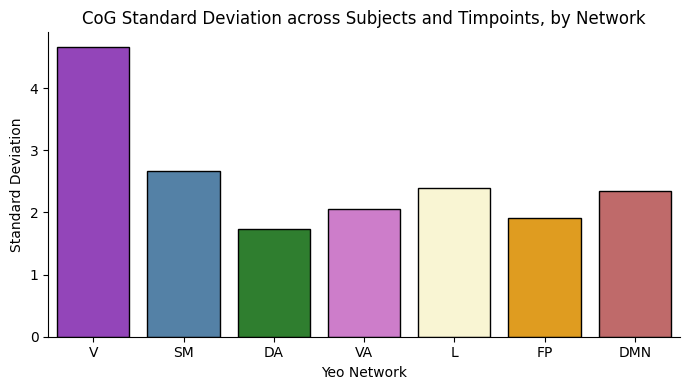

In [37]:
# Plot STD CoG

# --- 1. Define labels and palettes ---
yeo_labels = ["V", "SM", "DA", "VA", "L", "FP", "DMN"]

palette_labeled_networks = {
    'visual': 'darkorchid',
    'sensory motor': 'steelblue',
    'dorsal attention': 'forestgreen',
    'ventral attention': 'orchid',
    'limbic': 'lemonchiffon',
    'fronto parietal': 'orange',
    'DMN': 'indianred'
}

label_map = {
    "V": "visual",
    "SM": "sensory motor",
    "DA": "dorsal attention",
    "VA": "ventral attention",
    "L": "limbic",
    "FP": "fronto parietal",
    "DMN": "DMN"
}

palette_abbrev = {abbr: palette_labeled_networks[fullname] for abbr, fullname in label_map.items()}

# --- 2. Plot ---
colors = [palette_abbrev[label] for label in yeo_labels]

plt.figure(figsize=(7, 4))
sns.barplot(x=yeo_labels, y=yeo_cog_all_std, palette=colors, edgecolor='black')
plt.ylabel("Standard Deviation")
plt.xlabel("Yeo Network")
plt.title("CoG Standard Deviation across Subjects and Timpoints, by Network")
sns.despine()
plt.tight_layout()
plt.show()


   Network_1 Network_2  Levene_stat        p_value  Bonf_survival
0          V        SM  1710.316964   0.000000e+00           True
1          V        DA  4079.459391   0.000000e+00           True
2          V        VA  3104.874146   0.000000e+00           True
3          V         L  2239.183636   0.000000e+00           True
4          V        FP  3535.726003   0.000000e+00           True
5          V       DMN  2352.743306   0.000000e+00           True
6         SM        DA   839.322264  9.795820e-179           True
7         SM        VA   311.364791   7.349548e-69           True
8         SM         L    49.194785   2.435642e-12           True
9         SM        FP   530.946301  4.064421e-115           True
10        SM       DMN    69.684732   7.677715e-17           True
11        DA        VA   151.378438   1.366056e-34           True
12        DA         L   511.041798  5.862687e-111           True
13        DA        FP    33.600369   6.929570e-09           True
14        

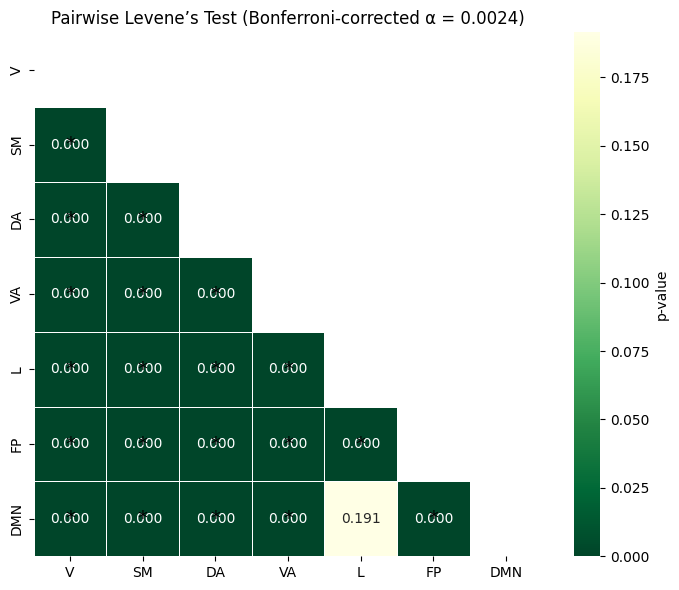

In [38]:
# Levene's test for equality of variance in CoG across subjects

n_networks = yeo_cog_all.shape[0]
network_names = ["V", "SM", "DA", "VA", "L", "FP", "DMN"]

# Compute all pairwise Levene tests
results = []
for (i, j) in itertools.combinations(range(n_networks), 2):
    stat, pval = levene(yeo_cog_all[i, :], yeo_cog_all[j, :], center='median')  # center='median' is more robust to non-normality
    results.append({
        "Network_1": network_names[i],
        "Network_2": network_names[j],
        "Levene_stat": stat,
        "p_value": pval
    })

# Convert to DataFrame for readability
levene_df = pd.DataFrame(results)

# Bonferroni correction
alpha_bonf = 0.05 / len(levene_df)

# Add column indicating which survive Bonferroni correction
levene_df["Bonf_survival"] = levene_df["p_value"] < alpha_bonf

print(levene_df)




### Plot heatmap triangle significance of Levene's test

# Compute Levene pairwise results
results = []
for (i, j) in itertools.combinations(range(n_networks), 2):
    stat, pval = levene(yeo_cog_all[i, :], yeo_cog_all[j, :], center='median')  # center='median' is more robust to non-normality
    results.append((i, j, stat, pval))

# Create matrix of p-values
p_matrix = np.ones((n_networks, n_networks))
for i, j, stat, pval in results:
    p_matrix[i, j] = pval
    p_matrix[j, i] = pval  # mirror

# Bonferroni correction threshold
alpha_bonf = 0.05 / len(results)

# Mask upper triangle for plotting
mask = np.triu(np.ones_like(p_matrix, dtype=bool))

# Create figure
plt.figure(figsize=(7, 6))
sns.heatmap(
    p_matrix,
    mask=mask,
    annot=True,
    fmt=".3f",
    cmap="YlGn_r",
    cbar_kws={"label": "p-value"},
    xticklabels=network_names,
    yticklabels=network_names,
    linewidths=0.5
)

# Overlay significance markers
for i in range(n_networks):
    for j in range(i):
        if p_matrix[i, j] < alpha_bonf:
            plt.text(j + 0.5, i + 0.5, "*", ha="center", va="center", color="black", fontsize=14)

plt.title("Pairwise Levene’s Test (Bonferroni-corrected α = {:.4f})".format(alpha_bonf))
plt.tight_layout()
plt.show()

## MAIN ANALYSIS: S-A axis expansion  (computed at **network-level**)

### Full sample

/tmp/ipykernel_192185/3008375398.py:67: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', frameon=False)


<Figure size 800x700 with 0 Axes>

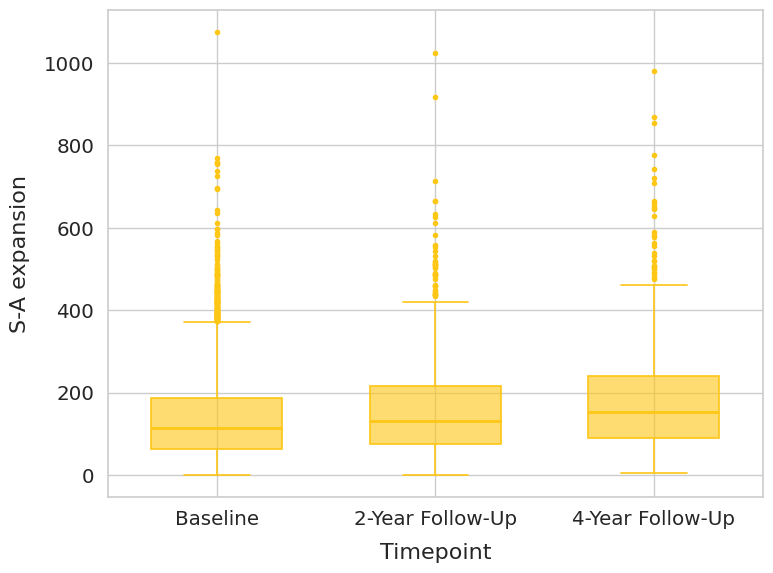

In [39]:
from matplotlib.patches import Patch
import matplotlib.colors as mcolors

timepoints = ["Baseline", "2-Year Follow-Up", "4-Year Follow-Up"]

alpha_map = {"Baseline": 0.6, "2-Year Follow-Up": 0.6, "4-Year Follow-Up": 0.6}  # 0.8, 0.6, 0.3
color_base = 'xkcd:golden yellow'


data = [
    SA_expansion_net_baseline,
    SA_expansion_net_fu2y,
    SA_expansion_net_fu4y
]

# --- Style setup (match your other figures) ---
sns.set_theme(style="whitegrid", font="DejaVu Sans", font_scale=1.3)
plt.rcParams["axes.linewidth"] = 1.2
plt.rcParams["boxplot.medianprops.linewidth"] = 2

# --- Create figure ---
plt.figure(figsize=(8, 7))

# Convert data into long-format DataFrame for Seaborn
df = pd.DataFrame({
    "Dispersion": np.concatenate(data),
    "Timepoint": np.repeat(timepoints, [len(d) for d in data])
})

# --- Style setup (consistent with your manuscript) ---
sns.set_theme(style="whitegrid", font="DejaVu Sans", font_scale=1.3)
plt.rcParams["axes.linewidth"] = 1.2
plt.rcParams["boxplot.medianprops.linewidth"] = 2


# --- Create figure and axes ---
fig, ax = plt.subplots(figsize=(8, 6))


# --- Function to draw boxplots with color and alpha ---
def draw_boxplots(ax, data):
    for i, tp in enumerate(timepoints):
        rgba = mcolors.to_rgba(color_base, alpha=alpha_map[tp])
        bp = ax.boxplot(
            data[i],
            positions=[i],
            widths=0.6,
            patch_artist=True,
            boxprops=dict(facecolor=rgba, color=color_base, linewidth=1.2),
            medianprops=dict(color=color_base, linewidth=2),
            whiskerprops=dict(color=color_base, linewidth=1.2),
            capprops=dict(color=color_base, linewidth=1.2),
            flierprops=dict(marker='o', markersize=3, alpha=1, markerfacecolor=color_base, markeredgecolor='xkcd:golden yellow')
            #,showfliers=False ## to remove outliers
        )
        


# --- Draw boxplots ---
draw_boxplots(ax, data)

# --- Axis labels ---
ax.set_xticks(np.arange(len(timepoints)))
ax.set_xticklabels(timepoints)
ax.set_xlabel("Timepoint", fontsize=16, labelpad=10)
ax.set_ylabel("S-A expansion", fontsize=16, labelpad=10)
ax.legend(loc='upper right', frameon=False)


#sns.despine(trim=True)
plt.tight_layout()

# --- Save or show ---
#plt.show()
plt.savefig(resdir + "supplementary/SA_expansion_net_full_sample/figures/boxplot_SA_expansion_net.svg", format="svg", bbox_inches="tight", dpi=300)


### Removing outliers + plotting + computing new metrics

#### Identifying outliers (using the interquartile range rule), i.e., 
- lower bound =  Q1 - 1.5 * IQR 
- upper bound = Q3 + 1.5 * IQR

In [40]:
### Identifying outliers per timepoint (as shown in boxplot)

data = [
    SA_expansion_net_baseline,
    SA_expansion_net_fu2y,
    SA_expansion_net_fu4y
]

timepoints = ["Baseline", "2-Year Follow-Up", "4-Year Follow-Up"]

for i in range(len(data)):

    print(f"Timepoint: {timepoints[i]}")
    
    
    # --- Compute quartiles and IQR ---
    Q1 = np.percentile(data[i], 25)
    Q3 = np.percentile(data[i], 75)
    IQR = Q3 - Q1
    
    # --- Define outlier bounds (Tukey 1.5×IQR rule) ---
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # --- Identify outliers ---
    outlier_mask = (data[i] < lower_bound) | (data[i] > upper_bound)
    outliers = data[i][outlier_mask]
    
    # --- Optional: view indices of outliers ---
    outlier_indices = np.where(outlier_mask)[0]
    
    print(f"Q1 = {Q1:.3f}, Q3 = {Q3:.3f}, IQR = {IQR:.3f}")
    print(f"Lower bound = {lower_bound:.3f}, Upper bound = {upper_bound:.3f}")
    print(f"Number of outliers = {outliers.size}")
    #print("Outlier values:", outliers)
    #print("Outlier indices:", outlier_indices)
    print("")


Timepoint: Baseline
Q1 = 62.842, Q3 = 186.793, IQR = 123.952
Lower bound = -123.086, Upper bound = 372.721
Number of outliers = 164

Timepoint: 2-Year Follow-Up
Q1 = 75.064, Q3 = 216.966, IQR = 141.902
Lower bound = -137.789, Upper bound = 429.819
Number of outliers = 38

Timepoint: 4-Year Follow-Up
Q1 = 90.657, Q3 = 240.163, IQR = 149.507
Lower bound = -133.603, Upper bound = 464.423
Number of outliers = 32



#### Identifying outliers across timepoints

In [42]:
# concatenate arrays across timepoints
SA_expansion_net_all = np.concatenate([SA_expansion_net_baseline, SA_expansion_net_fu2y, SA_expansion_net_fu4y])


# --- Compute quartiles and IQR across all timepoints ---
Q1 = np.percentile(SA_expansion_net_all, 25)
Q3 = np.percentile(SA_expansion_net_all, 75)
IQR = Q3 - Q1

# --- Define outlier bounds (Tukey 1.5×IQR rule) ---
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


# --- Identify outliers -> within each timpoint ---

# Baseline
outlier_mask_baseline = (SA_expansion_net_baseline < lower_bound) | (SA_expansion_net_baseline > upper_bound)
outliers_baseline = SA_expansion_net_baseline[outlier_mask_baseline]

# Fu2y
outlier_mask_fu2y = (SA_expansion_net_fu2y < lower_bound) | (SA_expansion_net_fu2y > upper_bound)
outliers_fu2y = SA_expansion_net_fu2y[outlier_mask_fu2y]

# Fu4y
outlier_mask_fu4y = (SA_expansion_net_fu4y < lower_bound) | (SA_expansion_net_fu4y > upper_bound)
outliers_fu4y = SA_expansion_net_fu4y[outlier_mask_fu4y]


# --- Indices of outliers (by timpoint)---
outlier_indices_baseline = np.where(outlier_mask_baseline)[0]
outlier_indices_fu2y = np.where(outlier_mask_fu2y)[0]
outlier_indices_fu4y = np.where(outlier_mask_fu4y)[0]


# --- Delete outliers by index (by timpeoint) for all relevant metrics ---

# S-A axis expansion metric
SA_expansion_net_baseline_rm_outliers = np.delete(SA_expansion_net_baseline, outlier_indices_baseline)
SA_expansion_net_fu2y_rm_outliers = np.delete(SA_expansion_net_fu2y, outlier_indices_fu2y)
SA_expansion_net_fu4y_rm_outliers = np.delete(SA_expansion_net_fu4y, outlier_indices_fu4y)

# CoG -> for plotting
yeo_cog_baseline_rm_outliers = np.delete(yeo_cog_baseline, outlier_indices_baseline, axis=1)
yeo_cog_fu2y_rm_outliers = np.delete(yeo_cog_fu2y, outlier_indices_fu2y, axis=1)
yeo_cog_fu4y_rm_outliers = np.delete(yeo_cog_fu4y, outlier_indices_fu4y, axis=1)

# sub IDs
sub_ID_baseline_rm_outliers = np.delete(sub_ID_baseline, outlier_indices_baseline)
sub_ID_fu2y_rm_outliers = np.delete(sub_ID_fu2y, outlier_indices_fu2y)
sub_ID_fu4y_rm_outliers = np.delete(sub_ID_fu4y, outlier_indices_fu4y)

# demographics dataframe -> for later analyses
abcd_demo_baseline_clean_rm_outliers = abcd_demo_baseline_clean.drop(outlier_indices_baseline, axis=0).reset_index(drop=True)  # really important to reset index everytime you drop, otherwise dropping via index != dropping via rows for later steps
abcd_demo_fu2y_clean_rm_outliers = abcd_demo_fu2y_clean.drop(outlier_indices_fu2y, axis=0).reset_index(drop=True)  # really important to reset index everytime you drop, otherwise dropping via index != dropping via rows for later steps
abcd_demo_fu4y_clean_rm_outliers = abcd_demo_fu4y_clean.drop(outlier_indices_fu4y, axis=0).reset_index(drop=True)  # really important to reset index everytime you drop, otherwise dropping via index != dropping via rows for later steps

# rcoef -> for later analyses
list_SA_axis_corr_to_ref_baseline_rm_outliers = np.delete(list_SA_axis_corr_to_ref_baseline, outlier_indices_baseline)
list_SA_axis_corr_to_ref_fu2y_rm_outliers = np.delete(list_SA_axis_corr_to_ref_fu2y, outlier_indices_fu2y) 
list_SA_axis_corr_to_ref_fu4y_rm_outliers = np.delete(list_SA_axis_corr_to_ref_fu4y, outlier_indices_fu4y)

# gradflip -> for later analyses
list_SA_axis_grad_num_baseline_rm_outliers = np.delete(list_SA_axis_grad_num_baseline, outlier_indices_baseline)
list_SA_axis_grad_num_fu2y_rm_outliers = np.delete(list_SA_axis_grad_num_fu2y, outlier_indices_fu2y)
list_SA_axis_grad_num_fu4y_rm_outliers = np.delete(list_SA_axis_grad_num_fu4y, outlier_indices_fu4y)

# GDs -> for later analyses / plotting
mean_gd_top10_baseline_rm_outliers = np.delete(mean_gd_top10_baseline, outlier_indices_baseline, axis=0)
yeo_mean_gd_baseline_rm_outliers = np.delete(yeo_mean_gd_baseline, outlier_indices_baseline, axis=1)
V_mean_gd_baseline_rm_outliers = np.delete(V_mean_gd_baseline, outlier_indices_baseline)
SM_mean_gd_baseline_rm_outliers = np.delete(SM_mean_gd_baseline, outlier_indices_baseline)
DA_mean_gd_baseline_rm_outliers = np.delete(DA_mean_gd_baseline, outlier_indices_baseline)
VA_mean_gd_baseline_rm_outliers = np.delete(VA_mean_gd_baseline, outlier_indices_baseline)
L_mean_gd_baseline_rm_outliers = np.delete(L_mean_gd_baseline, outlier_indices_baseline)
FP_mean_gd_baseline_rm_outliers = np.delete(FP_mean_gd_baseline, outlier_indices_baseline)
DMN_mean_gd_baseline_rm_outliers = np.delete(DMN_mean_gd_baseline, outlier_indices_baseline)

mean_gd_top10_fu2y_rm_outliers = np.delete(mean_gd_top10_fu2y, outlier_indices_fu2y, axis=0)
yeo_mean_gd_fu2y_rm_outliers = np.delete(yeo_mean_gd_fu2y, outlier_indices_fu2y, axis=1)
V_mean_gd_fu2y_rm_outliers = np.delete(V_mean_gd_fu2y, outlier_indices_fu2y)
SM_mean_gd_fu2y_rm_outliers = np.delete(SM_mean_gd_fu2y, outlier_indices_fu2y)
DA_mean_gd_fu2y_rm_outliers = np.delete(DA_mean_gd_fu2y, outlier_indices_fu2y)
VA_mean_gd_fu2y_rm_outliers = np.delete(VA_mean_gd_fu2y, outlier_indices_fu2y)
L_mean_gd_fu2y_rm_outliers = np.delete(L_mean_gd_fu2y, outlier_indices_fu2y)
FP_mean_gd_fu2y_rm_outliers = np.delete(FP_mean_gd_fu2y, outlier_indices_fu2y)
DMN_mean_gd_fu2y_rm_outliers = np.delete(DMN_mean_gd_fu2y, outlier_indices_fu2y)

mean_gd_top10_fu4y_rm_outliers = np.delete(mean_gd_top10_fu4y, outlier_indices_fu4y, axis=0)
yeo_mean_gd_fu4y_rm_outliers = np.delete(yeo_mean_gd_fu4y, outlier_indices_fu4y, axis=1)
V_mean_gd_fu4y_rm_outliers = np.delete(V_mean_gd_fu4y, outlier_indices_fu4y)
SM_mean_gd_fu4y_rm_outliers = np.delete(SM_mean_gd_fu4y, outlier_indices_fu4y)
DA_mean_gd_fu4y_rm_outliers = np.delete(DA_mean_gd_fu4y, outlier_indices_fu4y)
VA_mean_gd_fu4y_rm_outliers = np.delete(VA_mean_gd_fu4y, outlier_indices_fu4y)
L_mean_gd_fu4y_rm_outliers = np.delete(L_mean_gd_fu4y, outlier_indices_fu4y)
FP_mean_gd_fu4y_rm_outliers = np.delete(FP_mean_gd_fu4y, outlier_indices_fu4y)
DMN_mean_gd_fu4y_rm_outliers = np.delete(DMN_mean_gd_fu4y, outlier_indices_fu4y)


# FC strength -> for later analyses / plotting
fc_network_baseline_rm_outliers = np.delete(fc_network_baseline, outlier_indices_baseline, axis=0)
fc_binned_baseline_rm_outliers = np.delete(fc_binned_baseline, outlier_indices_baseline, axis=0)
mean_fc_strengths_baseline_rm_outliers = np.delete(mean_fc_strengths_baseline, outlier_indices_baseline, axis=0)

fc_network_fu2y_rm_outliers = np.delete(fc_network_fu2y, outlier_indices_fu2y, axis=0)
fc_binned_fu2y_rm_outliers = np.delete(fc_binned_fu2y, outlier_indices_fu2y, axis=0)
mean_fc_strengths_fu2y_rm_outliers = np.delete(mean_fc_strengths_fu2y, outlier_indices_fu2y, axis=0)

fc_network_fu4y_rm_outliers = np.delete(fc_network_fu4y, outlier_indices_fu4y, axis=0)
fc_binned_fu4y_rm_outliers = np.delete(fc_binned_fu4y, outlier_indices_fu4y, axis=0)
mean_fc_strengths_fu4y_rm_outliers = np.delete(mean_fc_strengths_fu4y, outlier_indices_fu4y, axis=0)

print("Definition of outliers across timepoints according to:")
print(f"Q1 = {Q1:.3f}, Q3 = {Q3:.3f}, IQR = {IQR:.3f}")
print(f"Lower bound = {lower_bound:.3f}, Upper bound = {upper_bound:.3f}")
#print(f"Number of outliers removed across timepoints = {outliers_baseline.size + outliers_fu2y.size + outliers_fu4y.size}")
#print("Outlier values:", outliers)
#print("Outlier indices:", outlier_indices)


Definition of outliers across timepoints according to:
Q1 = 68.592, Q3 = 203.165, IQR = 134.573
Lower bound = -133.268, Upper bound = 405.025


#### Plot individual S-A axis expansion

/tmp/ipykernel_222378/363730613.py:68: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', frameon=False)


<Figure size 800x700 with 0 Axes>

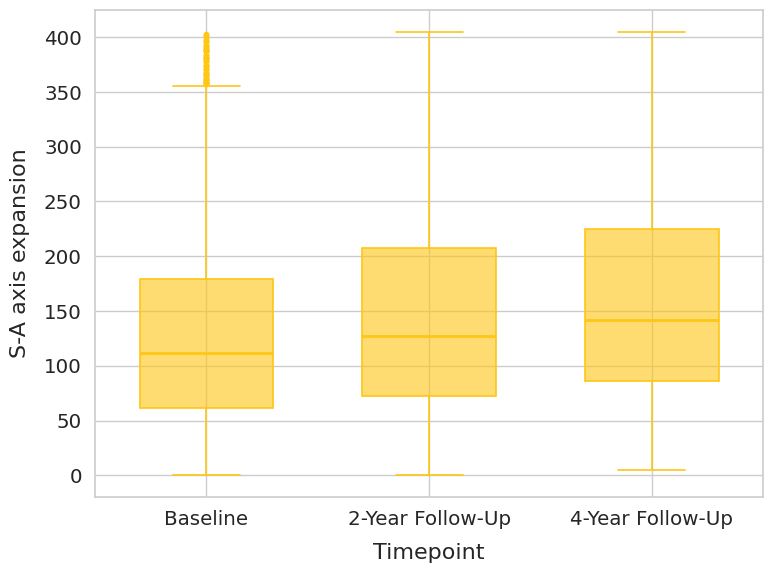

In [39]:
from matplotlib.patches import Patch
import matplotlib.colors as mcolors

timepoints = ["Baseline", "2-Year Follow-Up", "4-Year Follow-Up"]

alpha_map = {"Baseline": 0.6, "2-Year Follow-Up": 0.6, "4-Year Follow-Up": 0.6}  # 0.8, 0.6, 0.3
color_base = 'xkcd:golden yellow'


data = [
    SA_expansion_net_baseline_rm_outliers,
    SA_expansion_net_fu2y_rm_outliers,
    SA_expansion_net_fu4y_rm_outliers
]


# --- Style setup (match your other figures) ---
sns.set_theme(style="whitegrid", font="DejaVu Sans", font_scale=1.3)
plt.rcParams["axes.linewidth"] = 1.2
plt.rcParams["boxplot.medianprops.linewidth"] = 2

# --- Create figure ---
plt.figure(figsize=(8, 7))

# Convert data into long-format DataFrame for Seaborn
df = pd.DataFrame({
    "Dispersion": np.concatenate(data),
    "Timepoint": np.repeat(timepoints, [len(d) for d in data])
})

# --- Style setup (consistent with your manuscript) ---
sns.set_theme(style="whitegrid", font="DejaVu Sans", font_scale=1.3)
plt.rcParams["axes.linewidth"] = 1.2
plt.rcParams["boxplot.medianprops.linewidth"] = 2


# --- Create figure and axes ---
fig, ax = plt.subplots(figsize=(8, 6))


# --- Function to draw boxplots with color and alpha ---
def draw_boxplots(ax, data):
    for i, tp in enumerate(timepoints):
        rgba = mcolors.to_rgba(color_base, alpha=alpha_map[tp])
        bp = ax.boxplot(
            data[i],
            positions=[i],
            widths=0.6,
            patch_artist=True,
            boxprops=dict(facecolor=rgba, color=color_base, linewidth=1.2),
            medianprops=dict(color=color_base, linewidth=2),
            whiskerprops=dict(color=color_base, linewidth=1.2),
            capprops=dict(color=color_base, linewidth=1.2),
            flierprops=dict(marker='o', markersize=3, alpha=1, markerfacecolor=color_base, markeredgecolor='xkcd:golden yellow')
            #,showfliers=False ## to remove outliers
        )
        


# --- Draw boxplots ---
draw_boxplots(ax, data)

# --- Axis labels ---
ax.set_xticks(np.arange(len(timepoints)))
ax.set_xticklabels(timepoints)
ax.set_xlabel("Timepoint", fontsize=16, labelpad=10)
ax.set_ylabel("S-A axis expansion", fontsize=16, labelpad=10)
ax.legend(loc='upper right', frameon=False)


#sns.despine(trim=True)
plt.tight_layout()

# --- Save or show ---
#plt.show()
plt.savefig(resdir_fig + "boxplot_SA_expansion_net_rm_outliers.svg", format="svg", bbox_inches="tight", dpi=300)


#### Plot individual CoG

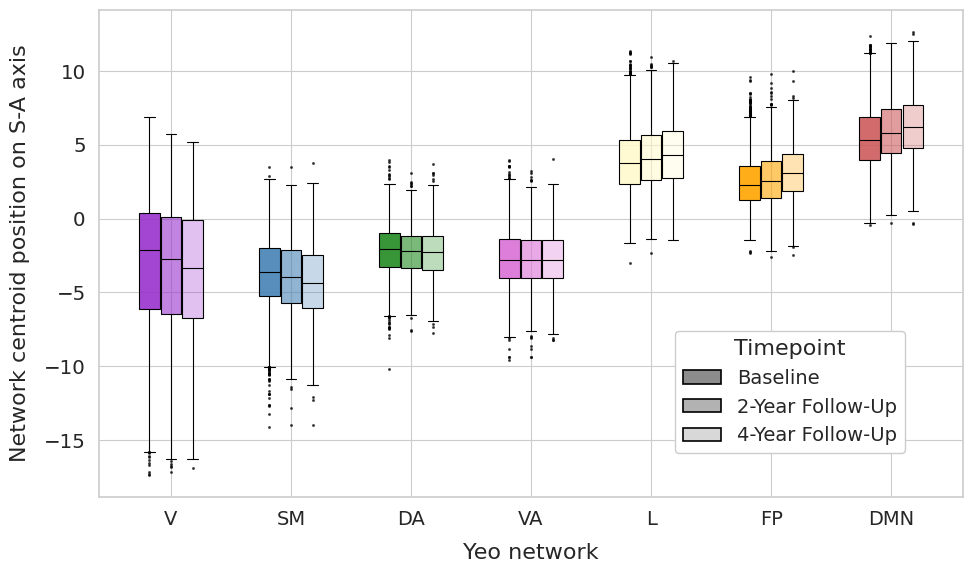

In [40]:
from matplotlib.patches import Patch
import matplotlib.colors as mcolors

# --- Palettes and mapping ---

yeo_labels = ["V", "SM", "DA", "VA", "L", "FP", "DMN"]

palette_labeled_networks = {
    'visual': 'darkorchid',
    'sensory motor': 'steelblue',
    'dorsal attention': 'forestgreen',
    'ventral attention': 'orchid',
    'limbic': 'lemonchiffon',
    'fronto parietal': 'orange',
    'DMN': 'indianred'
}

label_map = {
    "V": "visual",
    "SM": "sensory motor",
    "DA": "dorsal attention",
    "VA": "ventral attention",
    "L": "limbic",
    "FP": "fronto parietal",
    "DMN": "DMN"
}

palette_abbrev = {abbr: palette_labeled_networks[fullname] for abbr, fullname in label_map.items()}

# --- Make tidy df (optional, but we'll extract values directly) ---
def colvals(arr):
    # arr: (n_networks, n_subjects)
    return [arr[i, :] for i in range(arr.shape[0])]

data_baseline = colvals(yeo_cog_baseline_rm_outliers)
data_fu2y     = colvals(yeo_cog_fu2y_rm_outliers)
data_fu4y     = colvals(yeo_cog_fu4y_rm_outliers)

# --- Plot style ---
sns.set_theme(style="whitegrid", font="DejaVu Sans", font_scale=1.3)
plt.rcParams["axes.linewidth"] = 1.2
plt.rcParams["boxplot.medianprops.linewidth"] = 0.8
plt.rcParams["grid.linestyle"] = '-'
plt.rcParams["grid.linewidth"] = 0.8

fig, ax = plt.subplots(figsize=(10,6))

# --- Positioning ---
n_networks = len(yeo_labels)
network_pos = np.arange(n_networks)  # 0,1,2,...
box_width = 0.18   # width of each box
# offsets to produce three side-by-side boxes per network:
offsets = np.array([-box_width, 0.0, box_width])  # baseline, fu2y, fu4y

# alpha per timepoint
alpha_map = {"Baseline": 0.9, "2-Year Follow-Up": 0.6, "4-Year Follow-Up": 0.3}
timepoints = ["Baseline", "2-Year Follow-Up", "4-Year Follow-Up"]
all_data = [data_baseline, data_fu2y, data_fu4y]

# We will create a list of data in the order we will plot, and matching positions/colors/alphas
plot_data = []
positions = []
facecolors = []
edgecolors = []
alphas = []

for tp_idx, tp in enumerate(timepoints):
    arr = all_data[tp_idx]
    for net_idx in range(n_networks):
        plot_data.append(arr[net_idx])
        positions.append(network_pos[net_idx] + offsets[tp_idx])
        net_abbr = yeo_labels[net_idx]
        color = palette_abbrev[net_abbr]
        facecolors.append(color)
        edgecolors.append(color)
        alphas.append(alpha_map[tp])

# --- Draw boxplots with matplotlib, patch_artist=True to color boxes individually ---
bp = ax.boxplot(plot_data,
                positions=positions,
                widths=box_width * 0.95,
                patch_artist=True,
                manage_ticks=False,
                showfliers=True,
                boxprops=dict(linewidth=1.0),
                medianprops=dict(color='black', linewidth=1.5),
                whiskerprops=dict(color='black', linewidth=0.8),
                capprops=dict(color='black', linewidth=0.8),
                flierprops=dict(marker='o', markersize=1.2, alpha=0.6, markerfacecolor='black'))


# color each box individually (facecolor with alpha, opaque black edges)
for patch, fc, ec, a in zip(bp['boxes'], facecolors, edgecolors, alphas):
    rgba = mcolors.to_rgba(fc, alpha=a)   # apply alpha to facecolor only
    patch.set_facecolor(rgba)             # semi-transparent fill
    patch.set_edgecolor('black')          # always solid black border
    patch.set_linewidth(0.8)

# Also set whiskers/medians color to be slightly darker for visibility
for whisker in bp['whiskers']:
    whisker.set_color('black')
    whisker.set_linewidth(0.8)
for cap in bp['caps']:
    cap.set_color('black')
    cap.set_linewidth(0.8)
for median in bp['medians']:
    median.set_color('black')
    median.set_linewidth(0.8)


# --- X ticks: place at the network positions and label by abbreviation ---
ax.set_xticks(network_pos)
ax.set_xticklabels(yeo_labels, fontsize=14)

# Add small horizontal spacing so boxes don't touch
ax.set_xlim(-0.6, n_networks - 0.4)


# --- Create a legend for timepoint alpha (grey fill with constant black edge) ---
legend_patches = []
for tp in timepoints:
    rgba = mcolors.to_rgba('grey', alpha=alpha_map[tp])  # semi-transparent fill
    patch = Patch(facecolor=rgba, edgecolor='black', label=tp, linewidth=1.2)
    legend_patches.append(patch)

ax.legend(
    handles=legend_patches,
    title="Timepoint",
    bbox_to_anchor=(0.655, 0.36),
    loc="upper left",
    frameon=True,  # enable the frame
    facecolor='white',       # background color
    #edgecolor='grey',       # border color
    framealpha=1,          # opacity of the frame (1.0 = opaque)
    fontsize=14,
    title_fontsize=16
)


# Labels & polish
ax.set_xlabel("Yeo network", labelpad=10, fontsize=16)
ax.set_ylabel("Network centroid position on S-A axis", labelpad=10, fontsize=16)

plt.tight_layout()

# plt.show()
plt.savefig(resdir_fig + "boxplot_network_centroids_rm_outliers.svg", format="svg", bbox_inches="tight", dpi=300)


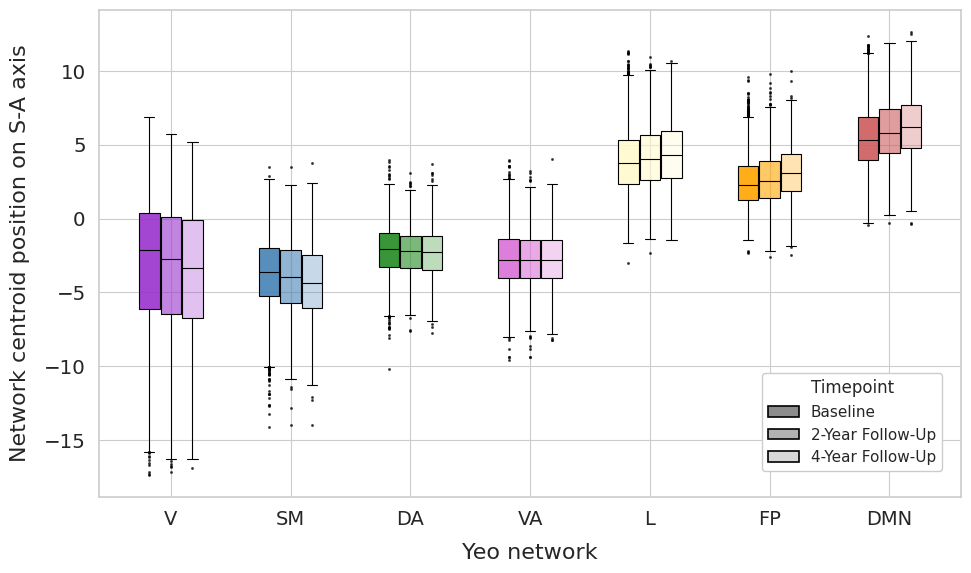

In [84]:
from matplotlib.patches import Patch
import matplotlib.colors as mcolors

# --- Palettes and mapping ---

yeo_labels = ["V", "SM", "DA", "VA", "L", "FP", "DMN"]

palette_labeled_networks = {
    'visual': 'darkorchid',
    'sensory motor': 'steelblue',
    'dorsal attention': 'forestgreen',
    'ventral attention': 'orchid',
    'limbic': 'lemonchiffon',
    'fronto parietal': 'orange',
    'DMN': 'indianred'
}

label_map = {
    "V": "visual",
    "SM": "sensory motor",
    "DA": "dorsal attention",
    "VA": "ventral attention",
    "L": "limbic",
    "FP": "fronto parietal",
    "DMN": "DMN"
}

palette_abbrev = {abbr: palette_labeled_networks[fullname] for abbr, fullname in label_map.items()}

# --- Make tidy df (optional, but we'll extract values directly) ---
def colvals(arr):
    # arr: (n_networks, n_subjects)
    return [arr[i, :] for i in range(arr.shape[0])]

data_baseline = colvals(yeo_cog_baseline_rm_outliers)
data_fu2y     = colvals(yeo_cog_fu2y_rm_outliers)
data_fu4y     = colvals(yeo_cog_fu4y_rm_outliers)

# --- Plot style ---
sns.set_theme(style="whitegrid", font="DejaVu Sans", font_scale=1.3)
plt.rcParams["axes.linewidth"] = 1.2
plt.rcParams["boxplot.medianprops.linewidth"] = 0.8
plt.rcParams["grid.linestyle"] = '-'
plt.rcParams["grid.linewidth"] = 0.8

fig, ax = plt.subplots(figsize=(10,6))

# --- Positioning ---
n_networks = len(yeo_labels)
network_pos = np.arange(n_networks)  # 0,1,2,...
box_width = 0.18   # width of each box
# offsets to produce three side-by-side boxes per network:
offsets = np.array([-box_width, 0.0, box_width])  # baseline, fu2y, fu4y

# alpha per timepoint
alpha_map = {"Baseline": 0.9, "2-Year Follow-Up": 0.6, "4-Year Follow-Up": 0.3}
timepoints = ["Baseline", "2-Year Follow-Up", "4-Year Follow-Up"]
all_data = [data_baseline, data_fu2y, data_fu4y]

# We will create a list of data in the order we will plot, and matching positions/colors/alphas
plot_data = []
positions = []
facecolors = []
edgecolors = []
alphas = []

for tp_idx, tp in enumerate(timepoints):
    arr = all_data[tp_idx]
    for net_idx in range(n_networks):
        plot_data.append(arr[net_idx])
        positions.append(network_pos[net_idx] + offsets[tp_idx])
        net_abbr = yeo_labels[net_idx]
        color = palette_abbrev[net_abbr]
        facecolors.append(color)
        edgecolors.append(color)
        alphas.append(alpha_map[tp])

# --- Draw boxplots with matplotlib, patch_artist=True to color boxes individually ---
bp = ax.boxplot(plot_data,
                positions=positions,
                widths=box_width * 0.95,
                patch_artist=True,
                manage_ticks=False,
                showfliers=True,
                boxprops=dict(linewidth=1.0),
                medianprops=dict(color='black', linewidth=1.5),
                whiskerprops=dict(color='black', linewidth=0.8),
                capprops=dict(color='black', linewidth=0.8),
                flierprops=dict(marker='o', markersize=1.2, alpha=0.6, markerfacecolor='black'))


# color each box individually (facecolor with alpha, opaque black edges)
for patch, fc, ec, a in zip(bp['boxes'], facecolors, edgecolors, alphas):
    rgba = mcolors.to_rgba(fc, alpha=a)   # apply alpha to facecolor only
    patch.set_facecolor(rgba)             # semi-transparent fill
    patch.set_edgecolor('black')          # always solid black border
    patch.set_linewidth(0.8)

# Also set whiskers/medians color to be slightly darker for visibility
for whisker in bp['whiskers']:
    whisker.set_color('black')
    whisker.set_linewidth(0.8)
for cap in bp['caps']:
    cap.set_color('black')
    cap.set_linewidth(0.8)
for median in bp['medians']:
    median.set_color('black')
    median.set_linewidth(0.8)


# --- X ticks: place at the network positions and label by abbreviation ---
ax.set_xticks(network_pos)
ax.set_xticklabels(yeo_labels, fontsize=14)

# Add small horizontal spacing so boxes don't touch
ax.set_xlim(-0.6, n_networks - 0.4)


# --- Create a legend for timepoint alpha (grey fill with constant black edge) ---
legend_patches = []
for tp in timepoints:
    rgba = mcolors.to_rgba('grey', alpha=alpha_map[tp])  # semi-transparent fill
    patch = Patch(facecolor=rgba, edgecolor='black', label=tp, linewidth=1.2)
    legend_patches.append(patch)

ax.legend(
    handles=legend_patches,
    title="Timepoint",
    #bbox_to_anchor=(0.72, 0.37),
    bbox_to_anchor=(0.76, 0.27),
    loc="upper left",
    frameon=True,
    facecolor='white',
    framealpha=1,
    
    # --- The "Shrinking" Settings ---
    fontsize=11,             # Reduced from 14
    title_fontsize=12,       # Reduced from 16
    #borderpad=0.4,           # Space between content and border (Default is 0.4)
    #labelspacing=0.3,        # Vertical space between entries (Default is 0.5)
    #handlelength=1.0,        # Width of the colored box (Default is 2.0)
    #handletextpad=0.5        # Space between box and text (Default is 0.8)
)


# Labels & polish
ax.set_xlabel("Yeo network", labelpad=10, fontsize=16)
ax.set_ylabel("Network centroid position on S-A axis", labelpad=10, fontsize=16)

plt.tight_layout()

# plt.show()
plt.savefig(resdir_fig + "boxplot_network_centroids_rm_outliers_s_legend.svg", format="svg", bbox_inches="tight", dpi=300)


#### Plots for mean GDs

In [51]:
# computing mean at the group level per seed regions for plotting
mean_gd_top10_all_group_rm_outliers = np.mean(np.concatenate((mean_gd_top10_baseline_rm_outliers, mean_gd_top10_fu2y_rm_outliers, mean_gd_top10_fu4y_rm_outliers), axis=0), axis=0)

In [52]:
mean_gd_top10_all_group_rm_outliers.shape

(400,)

##### Group-level plotted hemispheres

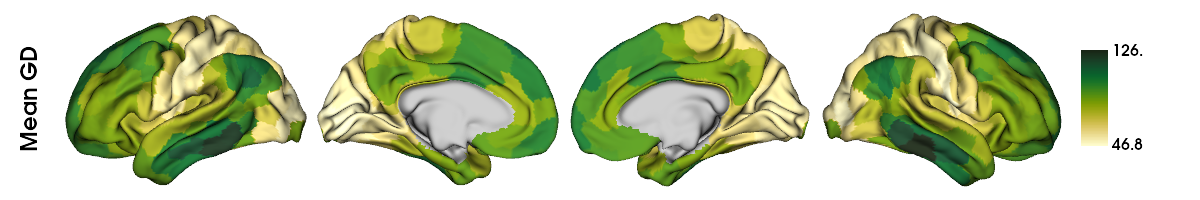

In [53]:
# defining labeling scheme and mask
labeling = load_parcellation('schaefer', scale=400, join=True)
surf_lh, surf_rh = load_conte69()
mask = labeling != 0

# map the gradient to the parcels
grad = map_to_labels(mean_gd_top10_all_group_rm_outliers, labeling, mask=mask, fill=np.nan)

plot = plot_hemispheres(surf_lh, 
                        surf_rh, 
                        array_name=grad, 
                        embed_nb = True, 
                        size=(1200, 200),
                        cmap='cmo.speed', 
                        nan_color = (0.7, 0.7, 0.7, 1),
                        color_bar=True,
                        label_text=['Mean GD'], 
                        zoom=1.55,
                        screenshot = False,
                        filename = resdir_fig+'plotted_hemispheres_mean_GD_all_group_rm_outliers.svg')

display(plot)

##### Plotted as a function of S-A axis loadings on adult template (per timepoint, and across timepoints)

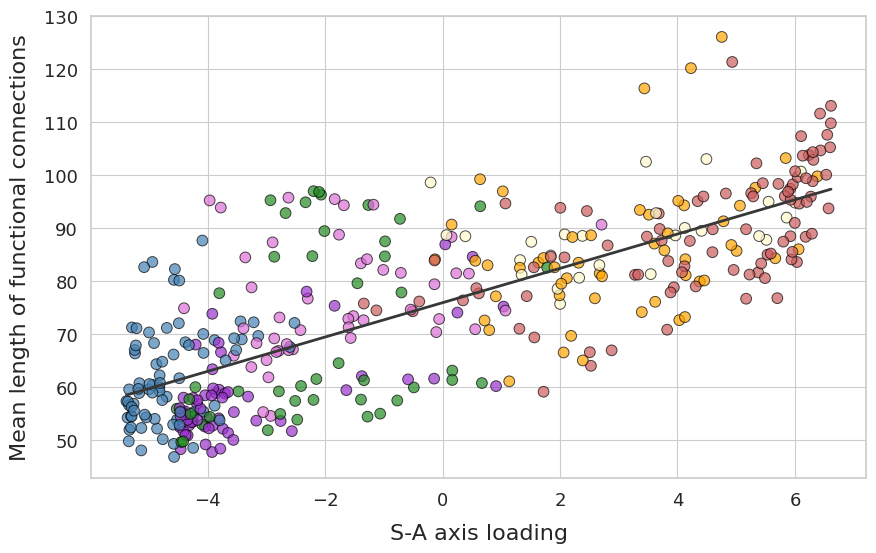

In [54]:
# make a dataframe containing the mpc and fc data (to make it plottable)
df_plot = pd.DataFrame({'SA_axis':  Margulies_gradients_schaefer400[0], 'Mean_GD': mean_gd_top10_all_group_rm_outliers})


# --- Plot setup ---
sns.set_theme(style="whitegrid", font="DejaVu Sans", font_scale=1.3)
plt.rcParams["axes.linewidth"] = 1.2
plt.rcParams["grid.linestyle"] = "-"
plt.rcParams["grid.linewidth"] = 0.8

fig, ax = plt.subplots(figsize=(10, 6))

# --- Scatterplot of all parcels (color-coded by Yeo7 network) ---
sns.scatterplot(
    data=df_plot,
    x="SA_axis", y="Mean_GD",
    hue=yeo7_networks_array_labels,
    palette=palette_labeled_networks,
    s=60, edgecolor="black", linewidth=0.7,
    ax=ax,
    alpha=0.7
)

# --- Single regression line ---
sns.regplot(
    data=df_plot,
    x="SA_axis", y="Mean_GD",
    scatter=False,
    ci=None,
    line_kws={
        "color": "xkcd:dark grey",
        "lw": 2
    },
    ax=ax
)

# --- 7. Aesthetics ---
ax.set_xlabel("S-A axis loading", fontsize=16, labelpad=10)
ax.set_ylabel("Mean length of functional connections", fontsize=16, labelpad=10)
ax.tick_params(labelsize=13)
#ax.set_title(f"Mean geodesic distance along S–A axis ({timepoint_to_plot})", fontsize=18, pad=15)
#sns.despine(ax=ax)


# --- 8. Legend (networks only) ---
#handles, labels = ax.get_legend_handles_labels()
ax.legend().remove()

# save figure in directory 
plt.savefig(resdir_fig+'scatter_mean_GD_by_SAaxis_rm_outliers.svg', dpi=300, bbox_inches="tight")  # bbox_inches is so that the figure doesn't get cut off when saving

In [55]:
stats.spearmanr(Margulies_gradients_schaefer400[0], mean_gd_top10_all_group_rm_outliers)

SignificanceResult(statistic=0.766547165919787, pvalue=1.465484775134573e-78)

In [56]:
spin_test_p, spin_test_d = spin_test(  
        Margulies_gradients_schaefer400[0], 
        mean_gd_top10_all_group_rm_outliers,
        surface_name='fsa5', 
        parcellation_name='schaefer_400',
        type='spearman', 
        n_rot=1000, 
        null_dist=True
    )

print(f"Spin permutation test p-value: {spin_test_p}")

permutation 100 of 1000
permutation 200 of 1000
permutation 300 of 1000
permutation 400 of 1000
permutation 500 of 1000
permutation 600 of 1000
permutation 700 of 1000
permutation 800 of 1000
permutation 900 of 1000
permutation 1000 of 1000
Spin permutation test p-value: 0.0


##### Variability in (individual-level) mean geodesic distances per network

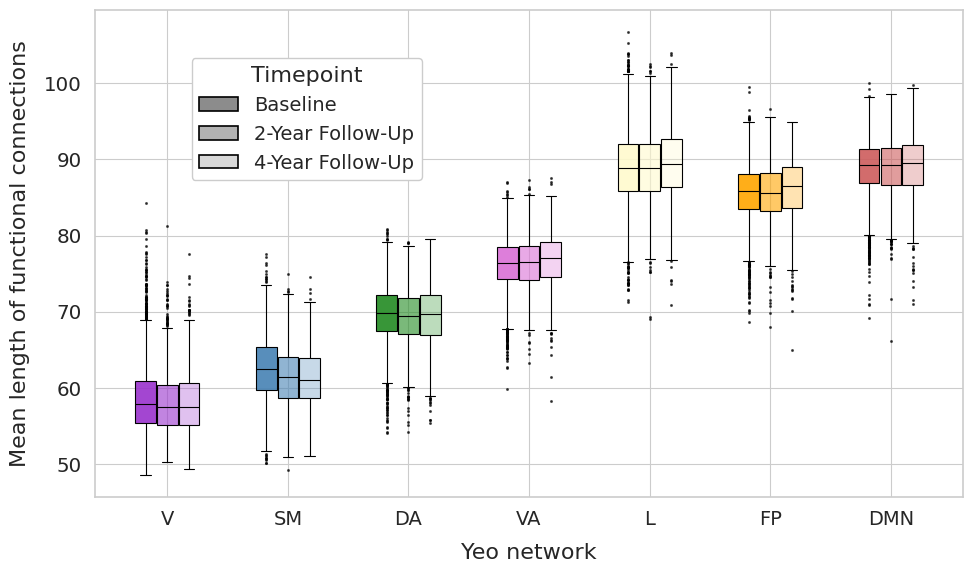

In [57]:
from matplotlib.patches import Patch
import matplotlib.colors as mcolors

# --- Palettes and mapping ---

yeo_labels = ["V", "SM", "DA", "VA", "L", "FP", "DMN"]

palette_labeled_networks = {
    'visual': 'darkorchid',
    'sensory motor': 'steelblue',
    'dorsal attention': 'forestgreen',
    'ventral attention': 'orchid',
    'limbic': 'lemonchiffon',
    'fronto parietal': 'orange',
    'DMN': 'indianred'
}

label_map = {
    "V": "visual",
    "SM": "sensory motor",
    "DA": "dorsal attention",
    "VA": "ventral attention",
    "L": "limbic",
    "FP": "fronto parietal",
    "DMN": "DMN"
}

palette_abbrev = {abbr: palette_labeled_networks[fullname] for abbr, fullname in label_map.items()}

# --- Make tidy df (optional, but we'll extract values directly) ---
def colvals(arr):
    # arr: (n_networks, n_subjects)
    return [arr[i, :] for i in range(arr.shape[0])]

data_baseline = colvals(yeo_mean_gd_baseline_rm_outliers)
data_fu2y     = colvals(yeo_mean_gd_fu2y_rm_outliers)
data_fu4y     = colvals(yeo_mean_gd_fu4y_rm_outliers)

# --- Plot style ---
sns.set_theme(style="whitegrid", font="DejaVu Sans", font_scale=1.3)
plt.rcParams["axes.linewidth"] = 1.2
plt.rcParams["boxplot.medianprops.linewidth"] = 0.8
plt.rcParams["grid.linestyle"] = '-'
plt.rcParams["grid.linewidth"] = 0.8

fig, ax = plt.subplots(figsize=(10,6))

# --- Positioning ---
n_networks = len(yeo_labels)
network_pos = np.arange(n_networks)  # 0,1,2,...
box_width = 0.18   # width of each box
# offsets to produce three side-by-side boxes per network:
offsets = np.array([-box_width, 0.0, box_width])  # baseline, fu2y, fu4y

# alpha per timepoint
alpha_map = {"Baseline": 0.9, "2-Year Follow-Up": 0.6, "4-Year Follow-Up": 0.3}
timepoints = ["Baseline", "2-Year Follow-Up", "4-Year Follow-Up"]
all_data = [data_baseline, data_fu2y, data_fu4y]

# We will create a list of data in the order we will plot, and matching positions/colors/alphas
plot_data = []
positions = []
facecolors = []
edgecolors = []
alphas = []

for tp_idx, tp in enumerate(timepoints):
    arr = all_data[tp_idx]
    for net_idx in range(n_networks):
        plot_data.append(arr[net_idx])
        positions.append(network_pos[net_idx] + offsets[tp_idx])
        net_abbr = yeo_labels[net_idx]
        color = palette_abbrev[net_abbr]
        facecolors.append(color)
        edgecolors.append(color)
        alphas.append(alpha_map[tp])

# --- Draw boxplots with matplotlib, patch_artist=True to color boxes individually ---
bp = ax.boxplot(plot_data,
                positions=positions,
                widths=box_width * 0.95,
                patch_artist=True,
                manage_ticks=False,
                showfliers=True,
                boxprops=dict(linewidth=1.0),
                medianprops=dict(color='black', linewidth=1.5),
                whiskerprops=dict(color='black', linewidth=0.8),
                capprops=dict(color='black', linewidth=0.8),
                flierprops=dict(marker='o', markersize=1.2, alpha=0.6, markerfacecolor='black'))


# color each box individually (facecolor with alpha, opaque black edges)
for patch, fc, ec, a in zip(bp['boxes'], facecolors, edgecolors, alphas):
    rgba = mcolors.to_rgba(fc, alpha=a)   # apply alpha to facecolor only
    patch.set_facecolor(rgba)             # semi-transparent fill
    patch.set_edgecolor('black')          # always solid black border
    patch.set_linewidth(0.8)

# Also set whiskers/medians color to be slightly darker for visibility
for whisker in bp['whiskers']:
    whisker.set_color('black')
    whisker.set_linewidth(0.8)
for cap in bp['caps']:
    cap.set_color('black')
    cap.set_linewidth(0.8)
for median in bp['medians']:
    median.set_color('black')
    median.set_linewidth(0.8)


# --- X ticks: place at the network positions and label by abbreviation ---
ax.set_xticks(network_pos)
ax.set_xticklabels(yeo_labels, fontsize=14)

# Add small horizontal spacing so boxes don't touch
ax.set_xlim(-0.6, n_networks - 0.4)


# --- Create a legend for timepoint alpha (grey fill with constant black edge) ---
legend_patches = []
for tp in timepoints:
    rgba = mcolors.to_rgba('grey', alpha=alpha_map[tp])  # semi-transparent fill
    patch = Patch(facecolor=rgba, edgecolor='black', label=tp, linewidth=1.2)
    legend_patches.append(patch)

ax.legend(
    handles=legend_patches,
    title="Timepoint",
    bbox_to_anchor=(0.1, 0.92),
    loc="upper left",
    frameon=True,  # enable the frame
    facecolor='white',       # background color
    #edgecolor='grey',       # border color
    framealpha=1,          # opacity of the frame (1.0 = opaque)
    fontsize=14,
    title_fontsize=16
)


# Labels & polish
ax.set_xlabel("Yeo network", labelpad=10, fontsize=16)
ax.set_ylabel("Mean length of functional connections", labelpad=10, fontsize=16)

plt.tight_layout()

# plt.show()
plt.savefig(resdir_fig + "boxplot_network_geodesic_distances_rm_outliers.svg", format="svg", bbox_inches="tight", dpi=300)


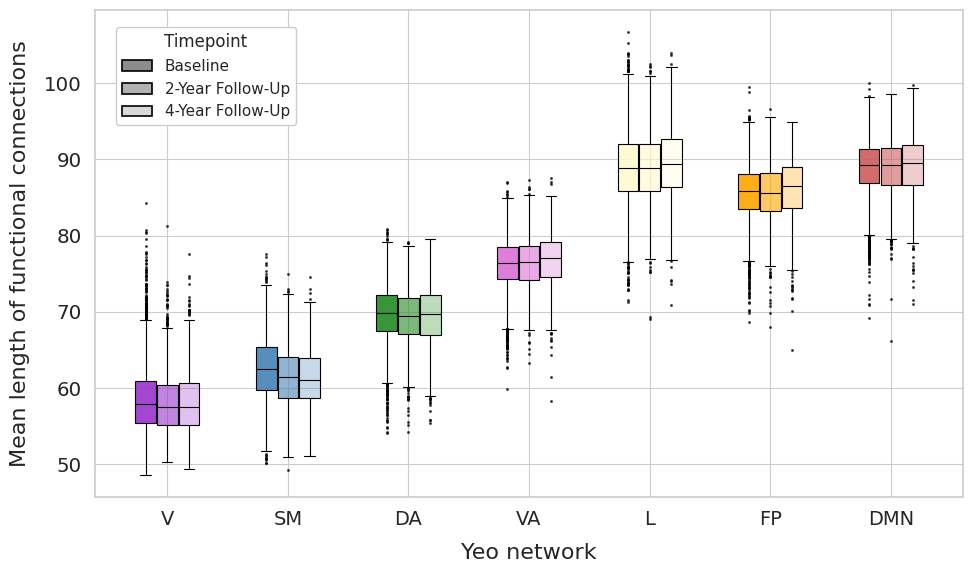

In [89]:
from matplotlib.patches import Patch
import matplotlib.colors as mcolors

# --- Palettes and mapping ---

yeo_labels = ["V", "SM", "DA", "VA", "L", "FP", "DMN"]

palette_labeled_networks = {
    'visual': 'darkorchid',
    'sensory motor': 'steelblue',
    'dorsal attention': 'forestgreen',
    'ventral attention': 'orchid',
    'limbic': 'lemonchiffon',
    'fronto parietal': 'orange',
    'DMN': 'indianred'
}

label_map = {
    "V": "visual",
    "SM": "sensory motor",
    "DA": "dorsal attention",
    "VA": "ventral attention",
    "L": "limbic",
    "FP": "fronto parietal",
    "DMN": "DMN"
}

palette_abbrev = {abbr: palette_labeled_networks[fullname] for abbr, fullname in label_map.items()}

# --- Make tidy df (optional, but we'll extract values directly) ---
def colvals(arr):
    # arr: (n_networks, n_subjects)
    return [arr[i, :] for i in range(arr.shape[0])]

data_baseline = colvals(yeo_mean_gd_baseline_rm_outliers)
data_fu2y     = colvals(yeo_mean_gd_fu2y_rm_outliers)
data_fu4y     = colvals(yeo_mean_gd_fu4y_rm_outliers)

# --- Plot style ---
sns.set_theme(style="whitegrid", font="DejaVu Sans", font_scale=1.3)
plt.rcParams["axes.linewidth"] = 1.2
plt.rcParams["boxplot.medianprops.linewidth"] = 0.8
plt.rcParams["grid.linestyle"] = '-'
plt.rcParams["grid.linewidth"] = 0.8

fig, ax = plt.subplots(figsize=(10,6))

# --- Positioning ---
n_networks = len(yeo_labels)
network_pos = np.arange(n_networks)  # 0,1,2,...
box_width = 0.18   # width of each box
# offsets to produce three side-by-side boxes per network:
offsets = np.array([-box_width, 0.0, box_width])  # baseline, fu2y, fu4y

# alpha per timepoint
alpha_map = {"Baseline": 0.9, "2-Year Follow-Up": 0.6, "4-Year Follow-Up": 0.3}
timepoints = ["Baseline", "2-Year Follow-Up", "4-Year Follow-Up"]
all_data = [data_baseline, data_fu2y, data_fu4y]

# We will create a list of data in the order we will plot, and matching positions/colors/alphas
plot_data = []
positions = []
facecolors = []
edgecolors = []
alphas = []

for tp_idx, tp in enumerate(timepoints):
    arr = all_data[tp_idx]
    for net_idx in range(n_networks):
        plot_data.append(arr[net_idx])
        positions.append(network_pos[net_idx] + offsets[tp_idx])
        net_abbr = yeo_labels[net_idx]
        color = palette_abbrev[net_abbr]
        facecolors.append(color)
        edgecolors.append(color)
        alphas.append(alpha_map[tp])

# --- Draw boxplots with matplotlib, patch_artist=True to color boxes individually ---
bp = ax.boxplot(plot_data,
                positions=positions,
                widths=box_width * 0.95,
                patch_artist=True,
                manage_ticks=False,
                showfliers=True,
                boxprops=dict(linewidth=1.0),
                medianprops=dict(color='black', linewidth=1.5),
                whiskerprops=dict(color='black', linewidth=0.8),
                capprops=dict(color='black', linewidth=0.8),
                flierprops=dict(marker='o', markersize=1.2, alpha=0.6, markerfacecolor='black'))


# color each box individually (facecolor with alpha, opaque black edges)
for patch, fc, ec, a in zip(bp['boxes'], facecolors, edgecolors, alphas):
    rgba = mcolors.to_rgba(fc, alpha=a)   # apply alpha to facecolor only
    patch.set_facecolor(rgba)             # semi-transparent fill
    patch.set_edgecolor('black')          # always solid black border
    patch.set_linewidth(0.8)

# Also set whiskers/medians color to be slightly darker for visibility
for whisker in bp['whiskers']:
    whisker.set_color('black')
    whisker.set_linewidth(0.8)
for cap in bp['caps']:
    cap.set_color('black')
    cap.set_linewidth(0.8)
for median in bp['medians']:
    median.set_color('black')
    median.set_linewidth(0.8)


# --- X ticks: place at the network positions and label by abbreviation ---
ax.set_xticks(network_pos)
ax.set_xticklabels(yeo_labels, fontsize=14)

# Add small horizontal spacing so boxes don't touch
ax.set_xlim(-0.6, n_networks - 0.4)


# --- Create a legend for timepoint alpha (grey fill with constant black edge) ---
legend_patches = []
for tp in timepoints:
    rgba = mcolors.to_rgba('grey', alpha=alpha_map[tp])  # semi-transparent fill
    patch = Patch(facecolor=rgba, edgecolor='black', label=tp, linewidth=1.2)
    legend_patches.append(patch)

ax.legend(
    handles=legend_patches,
    title="Timepoint",
    bbox_to_anchor=(0.015, 0.98),
    #bbox_to_anchor=(0.76, 0.27),
    loc="upper left",
    frameon=True,
    facecolor='white',
    framealpha=1,
    
    # --- The "Shrinking" Settings ---
    fontsize=11,             # Reduced from 14
    title_fontsize=12,       # Reduced from 16
    #borderpad=0.4,           # Space between content and border (Default is 0.4)
    #labelspacing=0.3,        # Vertical space between entries (Default is 0.5)
    #handlelength=1.0,        # Width of the colored box (Default is 2.0)
    #handletextpad=0.5        # Space between box and text (Default is 0.8)
)

# Labels & polish
ax.set_xlabel("Yeo network", labelpad=10, fontsize=16)
ax.set_ylabel("Mean length of functional connections", labelpad=10, fontsize=16)

plt.tight_layout()

# plt.show()
plt.savefig(resdir_fig + "boxplot_network_geodesic_distances_rm_outliers_s_legend.svg", format="svg", bbox_inches="tight", dpi=300)


#### Computing mean GDs in terms of length short/medium/long range connections by region, per subject

In [58]:
# Baseline

mean_gd_short_node_baseline_rm_outliers = []
mean_gd_medium_node_baseline_rm_outliers = []
mean_gd_long_node_baseline_rm_outliers = []


for i in range(len(mean_gd_top10_baseline_rm_outliers)):
    
    ### Compute the bin boundaries
    # np linespace: Return evenly spaced numbers over a specified interval [start, stop, number of samples to generate (3 quantiles +1 for boundary]): array([0, 0.33, 0.67, 1])
    # np qunatile: Compute the q-th quantile of the data along the specified axis [input array, sequence of probabilities of the quantiles to compute]
    quantiles = np.quantile(mean_gd_top10_baseline_rm_outliers[i], np.linspace(0, 1, 3+1))
    
    # Assign each value to a bin -> get bin indices 0,1,2 for quantile-based bins
    # np digitize: Return the indices of the bins to which each value in input array belongs [array to be binned, array of bins]
    bin_idx = np.digitize(mean_gd_top10_baseline_rm_outliers[i], quantiles[1:-1], right=True)
    
    
    ### Get the mean of the short, medium, and long connections
    
    # Compute mean for each bin (0=short, 1=medium, 2=long)
    mean_gd_sub_short = mean_gd_top10_baseline_rm_outliers[i][bin_idx == 0].mean()
    mean_gd_sub_medium = mean_gd_top10_baseline_rm_outliers[i][bin_idx == 1].mean()
    mean_gd_sub_long = mean_gd_top10_baseline_rm_outliers[i][bin_idx == 2].mean()

    # append to list
    mean_gd_short_node_baseline_rm_outliers.append(mean_gd_sub_short)
    mean_gd_medium_node_baseline_rm_outliers.append(mean_gd_sub_medium)
    mean_gd_long_node_baseline_rm_outliers.append(mean_gd_sub_long)


mean_gd_short_node_baseline_rm_outliers = np.array(mean_gd_short_node_baseline_rm_outliers)
mean_gd_medium_node_baseline_rm_outliers = np.array(mean_gd_medium_node_baseline_rm_outliers)
mean_gd_long_node_baseline_rm_outliers = np.array(mean_gd_long_node_baseline_rm_outliers)




# Fu2y

mean_gd_short_node_fu2y_rm_outliers = []
mean_gd_medium_node_fu2y_rm_outliers = []
mean_gd_long_node_fu2y_rm_outliers = []


for i in range(len(mean_gd_top10_fu2y_rm_outliers)):
    
    ### Compute the bin boundaries
    # np linespace: Return evenly spaced numbers over a specified interval [start, stop, number of samples to generate (3 quantiles +1 for boundary]): array([0, 0.33, 0.67, 1])
    # np qunatile: Compute the q-th quantile of the data along the specified axis [input array, sequence of probabilities of the quantiles to compute]
    quantiles = np.quantile(mean_gd_top10_fu2y_rm_outliers[i], np.linspace(0, 1, 3+1))
    
    # Assign each value to a bin -> get bin indices 0,1,2 for quantile-based bins
    # np digitize: Return the indices of the bins to which each value in input array belongs [array to be binned, array of bins]
    bin_idx = np.digitize(mean_gd_top10_fu2y_rm_outliers[i], quantiles[1:-1], right=True)
    
    
    ### Get the mean of the short, medium, and long connections
    
    # Compute mean for each bin (0=short, 1=medium, 2=long)
    mean_gd_sub_short = mean_gd_top10_fu2y_rm_outliers[i][bin_idx == 0].mean()
    mean_gd_sub_medium = mean_gd_top10_fu2y_rm_outliers[i][bin_idx == 1].mean()
    mean_gd_sub_long = mean_gd_top10_fu2y_rm_outliers[i][bin_idx == 2].mean()

    # append to list
    mean_gd_short_node_fu2y_rm_outliers.append(mean_gd_sub_short)
    mean_gd_medium_node_fu2y_rm_outliers.append(mean_gd_sub_medium)
    mean_gd_long_node_fu2y_rm_outliers.append(mean_gd_sub_long)


mean_gd_short_node_fu2y_rm_outliers = np.array(mean_gd_short_node_fu2y_rm_outliers)
mean_gd_medium_node_fu2y_rm_outliers = np.array(mean_gd_medium_node_fu2y_rm_outliers)
mean_gd_long_node_fu2y_rm_outliers = np.array(mean_gd_long_node_fu2y_rm_outliers)




# Fu4y
mean_gd_short_node_fu4y_rm_outliers = []
mean_gd_medium_node_fu4y_rm_outliers = []
mean_gd_long_node_fu4y_rm_outliers = []


for i in range(len(mean_gd_top10_fu4y_rm_outliers)):
    
    ### Compute the bin boundaries
    # np linespace: Return evenly spaced numbers over a specified interval [start, stop, number of samples to generate (3 quantiles +1 for boundary]): array([0, 0.33, 0.67, 1])
    # np qunatile: Compute the q-th quantile of the data along the specified axis [input array, sequence of probabilities of the quantiles to compute]
    quantiles = np.quantile(mean_gd_top10_fu4y_rm_outliers[i], np.linspace(0, 1, 3+1))
    
    # Assign each value to a bin -> get bin indices 0,1,2 for quantile-based bins
    # np digitize: Return the indices of the bins to which each value in input array belongs [array to be binned, array of bins]
    bin_idx = np.digitize(mean_gd_top10_fu4y_rm_outliers[i], quantiles[1:-1], right=True)
    
    
    ### Get the mean of the short, medium, and long connections
    
    # Compute mean for each bin (0=short, 1=medium, 2=long)
    mean_gd_sub_short = mean_gd_top10_fu4y_rm_outliers[i][bin_idx == 0].mean()
    mean_gd_sub_medium = mean_gd_top10_fu4y_rm_outliers[i][bin_idx == 1].mean()
    mean_gd_sub_long = mean_gd_top10_fu4y_rm_outliers[i][bin_idx == 2].mean()

    # append to list
    mean_gd_short_node_fu4y_rm_outliers.append(mean_gd_sub_short)
    mean_gd_medium_node_fu4y_rm_outliers.append(mean_gd_sub_medium)
    mean_gd_long_node_fu4y_rm_outliers.append(mean_gd_sub_long)


mean_gd_short_node_fu4y_rm_outliers = np.array(mean_gd_short_node_fu4y_rm_outliers)
mean_gd_medium_node_fu4y_rm_outliers = np.array(mean_gd_medium_node_fu4y_rm_outliers)
mean_gd_long_node_fu4y_rm_outliers = np.array(mean_gd_long_node_fu4y_rm_outliers)


In [59]:
mean_gd_medium_node_baseline_rm_outliers.shape

(3950,)

In [60]:
mean_gd_medium_node_fu4y_rm_outliers.shape

(906,)

In [61]:
mean_gd_long_node_fu4y_rm_outliers.shape

(906,)

#### Plots for mean FC strength

##### Variability in (individual-level) mean geodesic distances per network

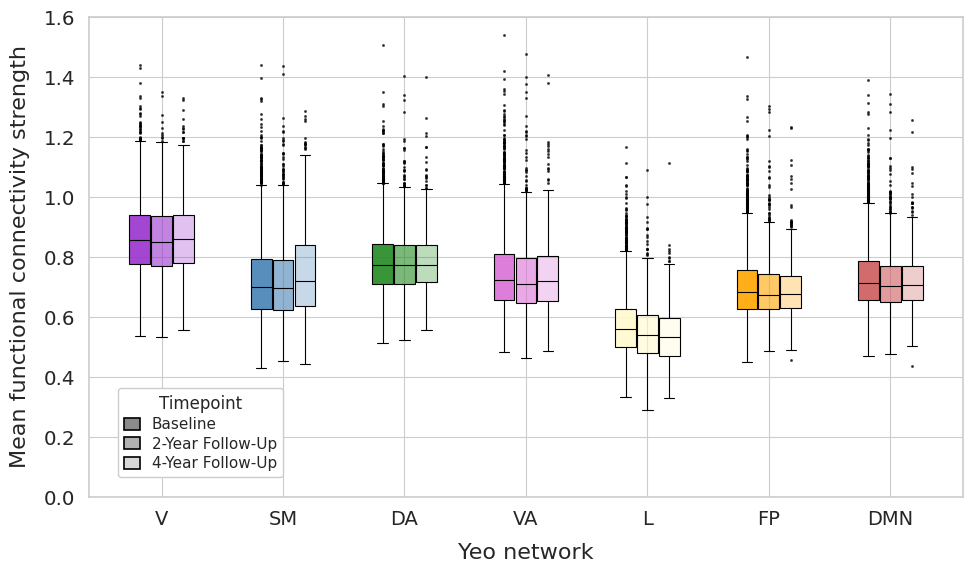

In [62]:
from matplotlib.patches import Patch
import matplotlib.colors as mcolors

# --- Palettes and mapping ---

yeo_labels = ["V", "SM", "DA", "VA", "L", "FP", "DMN"]

palette_labeled_networks = {
    'visual': 'darkorchid',
    'sensory motor': 'steelblue',
    'dorsal attention': 'forestgreen',
    'ventral attention': 'orchid',
    'limbic': 'lemonchiffon',
    'fronto parietal': 'orange',
    'DMN': 'indianred'
}

label_map = {
    "V": "visual",
    "SM": "sensory motor",
    "DA": "dorsal attention",
    "VA": "ventral attention",
    "L": "limbic",
    "FP": "fronto parietal",
    "DMN": "DMN"
}

palette_abbrev = {abbr: palette_labeled_networks[fullname] for abbr, fullname in label_map.items()}

# --- Make tidy df (optional, but we'll extract values directly) ---
def colvals(arr):
    # arr: (n_networks, n_subjects)
    return [arr[i, :] for i in range(arr.shape[0])]

data_baseline = colvals(fc_network_baseline_rm_outliers.T)
data_fu2y     = colvals(fc_network_fu2y_rm_outliers.T)
data_fu4y     = colvals(fc_network_fu4y_rm_outliers.T)

# --- Plot style ---
sns.set_theme(style="whitegrid", font="DejaVu Sans", font_scale=1.3)
plt.rcParams["axes.linewidth"] = 1.2
plt.rcParams["boxplot.medianprops.linewidth"] = 0.8
plt.rcParams["grid.linestyle"] = '-'
plt.rcParams["grid.linewidth"] = 0.8

fig, ax = plt.subplots(figsize=(10,6))

# --- Positioning ---
n_networks = len(yeo_labels)
network_pos = np.arange(n_networks)  # 0,1,2,...
box_width = 0.18   # width of each box
# offsets to produce three side-by-side boxes per network:
offsets = np.array([-box_width, 0.0, box_width])  # baseline, fu2y, fu4y

# alpha per timepoint
alpha_map = {"Baseline": 0.9, "2-Year Follow-Up": 0.6, "4-Year Follow-Up": 0.3}
timepoints = ["Baseline", "2-Year Follow-Up", "4-Year Follow-Up"]
all_data = [data_baseline, data_fu2y, data_fu4y]

# We will create a list of data in the order we will plot, and matching positions/colors/alphas
plot_data = []
positions = []
facecolors = []
edgecolors = []
alphas = []

for tp_idx, tp in enumerate(timepoints):
    arr = all_data[tp_idx]
    for net_idx in range(n_networks):
        plot_data.append(arr[net_idx])
        positions.append(network_pos[net_idx] + offsets[tp_idx])
        net_abbr = yeo_labels[net_idx]
        color = palette_abbrev[net_abbr]
        facecolors.append(color)
        edgecolors.append(color)
        alphas.append(alpha_map[tp])

# --- Draw boxplots with matplotlib, patch_artist=True to color boxes individually ---
bp = ax.boxplot(plot_data,
                positions=positions,
                widths=box_width * 0.95,
                patch_artist=True,
                manage_ticks=False,
                showfliers=True,
                boxprops=dict(linewidth=1.0),
                medianprops=dict(color='black', linewidth=1.5),
                whiskerprops=dict(color='black', linewidth=0.8),
                capprops=dict(color='black', linewidth=0.8),
                flierprops=dict(marker='o', markersize=1.2, alpha=0.6, markerfacecolor='black'))


# color each box individually (facecolor with alpha, opaque black edges)
for patch, fc, ec, a in zip(bp['boxes'], facecolors, edgecolors, alphas):
    rgba = mcolors.to_rgba(fc, alpha=a)   # apply alpha to facecolor only
    patch.set_facecolor(rgba)             # semi-transparent fill
    patch.set_edgecolor('black')          # always solid black border
    patch.set_linewidth(0.8)

# Also set whiskers/medians color to be slightly darker for visibility
for whisker in bp['whiskers']:
    whisker.set_color('black')
    whisker.set_linewidth(0.8)
for cap in bp['caps']:
    cap.set_color('black')
    cap.set_linewidth(0.8)
for median in bp['medians']:
    median.set_color('black')
    median.set_linewidth(0.8)


# --- X ticks: place at the network positions and label by abbreviation ---
ax.set_xticks(network_pos)
ax.set_xticklabels(yeo_labels, fontsize=14)

# Add small horizontal spacing so boxes don't touch
ax.set_xlim(-0.6, n_networks - 0.4)


# --- Create a legend for timepoint alpha (grey fill with constant black edge) ---
legend_patches = []
for tp in timepoints:
    rgba = mcolors.to_rgba('grey', alpha=alpha_map[tp])  # semi-transparent fill
    patch = Patch(facecolor=rgba, edgecolor='black', label=tp, linewidth=1.2)
    legend_patches.append(patch)

# NEED TO CHANGE LOCATION OF LEGEND
ax.legend(
    handles=legend_patches,
    title="Timepoint",
    bbox_to_anchor=(0.025, 0.025),
    loc="lower left",
    frameon=True,  # enable the frame
    facecolor='white',       # background color
    #edgecolor='grey',       # border color
    framealpha=1,          # opacity of the frame (1.0 = opaque)
    #fontsize=14,
    #title_fontsize=16

    # to make it smaller than the usual:
    fontsize=11,
    title_fontsize=12,
    borderpad=0.4,
    labelspacing=0.3,
    handlelength=1,
    handleheight=0.8
)


# Labels & polish
ax.set_xlabel("Yeo network", labelpad=10, fontsize=16)
ax.set_ylabel("Mean functional connectivity strength", labelpad=10, fontsize=16)

ax.set_ylim(bottom=0)

plt.tight_layout()

# plt.show()
plt.savefig(resdir_fig + "boxplot_network_fc_strength_rm_outliers.svg", format="svg", bbox_inches="tight", dpi=300)


##### Mean across all timepoints in FC strength of top 10% connections by seed region

In [63]:
mean_fc_strengths_all_rm_outliers = np.mean(mean_fc_strengths_baseline_rm_outliers, axis=0) + np.mean(mean_fc_strengths_fu2y_rm_outliers, axis=0) + np.mean(mean_fc_strengths_fu4y_rm_outliers, axis=0)

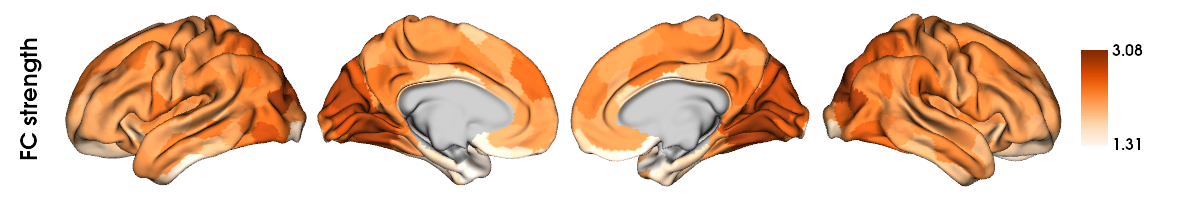

In [64]:
# defining labeling scheme and mask
labeling = load_parcellation('schaefer', scale=400, join=True)
surf_lh, surf_rh = load_conte69()
mask = labeling != 0

# map the gradient to the parcels
grad = map_to_labels(mean_fc_strengths_all_rm_outliers, labeling, mask=mask, fill=np.nan)

plot = plot_hemispheres(surf_lh, 
                        surf_rh, 
                        array_name=grad, 
                        embed_nb = True, 
                        size=(1200, 200),
                        cmap='Oranges', 
                        nan_color = (0.7, 0.7, 0.7, 1),
                        color_bar=True, 
                        label_text=['FC strength'], 
                        zoom=1.55,
                        screenshot = False,
                        filename = resdir_fig+'plotted_hemispheres_mean_FC_all_group_rm_outliers.png')

display(plot)

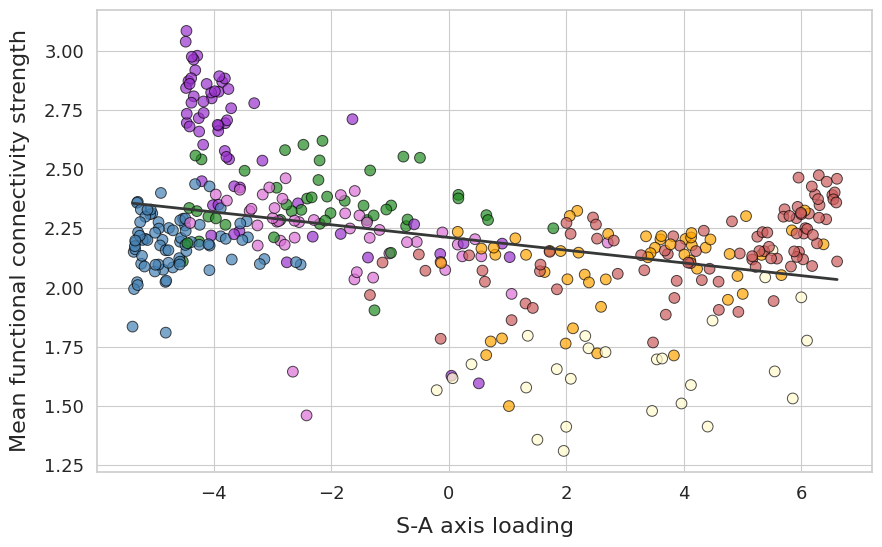

In [65]:
# make a dataframe containing the mpc and fc data (to make it plottable)
df_plot = pd.DataFrame({'SA_axis':  Margulies_gradients_schaefer400[0], 'Mean_FC': mean_fc_strengths_all_rm_outliers})


# --- Plot setup ---
sns.set_theme(style="whitegrid", font="DejaVu Sans", font_scale=1.3)
plt.rcParams["axes.linewidth"] = 1.2
plt.rcParams["grid.linestyle"] = "-"
plt.rcParams["grid.linewidth"] = 0.8

fig, ax = plt.subplots(figsize=(10, 6))

# --- Scatterplot of all parcels (color-coded by Yeo7 network) ---
sns.scatterplot(
    data=df_plot,
    x="SA_axis", y="Mean_FC",
    hue=yeo7_networks_array_labels,
    palette=palette_labeled_networks,
    s=60, edgecolor="black", linewidth=0.7,
    ax=ax,
    alpha=0.7
)

# --- Single regression line ---
sns.regplot(
    data=df_plot,
    x="SA_axis", y="Mean_FC",
    scatter=False,
    ci=None,
    line_kws={
        "color": "xkcd:dark grey",
        "lw": 2
    },
    ax=ax
)

# --- 7. Aesthetics ---
ax.set_xlabel("S-A axis loading", fontsize=16, labelpad=10)
ax.set_ylabel("Mean functional connectivity strength", fontsize=16, labelpad=10)
ax.tick_params(labelsize=13)
#ax.set_title(f"Mean geodesic distance along S–A axis ({timepoint_to_plot})", fontsize=18, pad=15)
#sns.despine(ax=ax)


# --- 8. Legend (networks only) ---
#handles, labels = ax.get_legend_handles_labels()
ax.legend().remove()

# save figure in directory 
plt.savefig(resdir_fig+'scatter_mean_FC_by_SAaxis_rm_outliers.svg', dpi=300, bbox_inches="tight")  # bbox_inches is so that the figure doesn't get cut off when saving

In [66]:
stats.spearmanr(Margulies_gradients_schaefer400[0], mean_fc_strengths_all_rm_outliers)

SignificanceResult(statistic=-0.3040061500384377, pvalue=5.344267390752793e-10)

In [97]:
spin_test_p, spin_test_d = spin_test(  
        Margulies_gradients_schaefer400[0], 
        mean_fc_strengths_all_rm_outliers,
        surface_name='fsa5', 
        parcellation_name='schaefer_400',
        type='spearman', 
        n_rot=1000, 
        null_dist=True
    )

print(f"Spin permutation test p-value: {spin_test_p}")

permutation 100 of 1000
permutation 200 of 1000
permutation 300 of 1000
permutation 400 of 1000
permutation 500 of 1000
permutation 600 of 1000
permutation 700 of 1000
permutation 800 of 1000
permutation 900 of 1000
permutation 1000 of 1000
Spin permutation test p-value: 0.0095


### Export S-A axis expansion computed at parcel level with outliers removed + corresponding demographics dataframe + corresponding rcoef/gradflip -> for R analyses

In [97]:
# Safety check that sub ID list and demographics subjects are identical (order and elements) - this was done in the cleaning step normally
np.array_equal(np.array(sub_ID_baseline_rm_outliers), np.array(abcd_demo_baseline_clean_rm_outliers.src_subject_id_fmt))

True

In [98]:
# Safety check that sub ID list and demographics subjects are identical (order and elements) - this was done in the cleaning step normally
np.array_equal(np.array(sub_ID_fu2y_rm_outliers), np.array(abcd_demo_fu2y_clean_rm_outliers.src_subject_id_fmt))

True

In [99]:
# Safety check that sub ID list and demographics subjects are identical (order and elements) - this was done in the cleaning step normally
np.array_equal(np.array(sub_ID_fu4y_rm_outliers), np.array(abcd_demo_fu4y_clean_rm_outliers.src_subject_id_fmt))

True

In [ ]:

fc_network_baseline_rm_outliers = np.delete(fc_network_baseline, outlier_indices_baseline, axis=0)
fc_binned_baseline_rm_outliers = np.delete(fc_binned_baseline, outlier_indices_baseline, axis=0)

In [101]:
### export S-A axis expansion metrics (+ demographics + rcoef/gradflip/GDs for R analyses) with removed outliers

## Matfiles

# baseline
mdict = {'SA_expansion_net_baseline': SA_expansion_net_baseline_rm_outliers, 'list_SA_axis_corr_to_ref_baseline': list_SA_axis_corr_to_ref_baseline_rm_outliers, 
         'list_SA_axis_grad_num_baseline': list_SA_axis_grad_num_baseline_rm_outliers, 'mean_gd_top10_baseline': mean_gd_top10_baseline_rm_outliers,
         'V_mean_gd_baseline': V_mean_gd_baseline_rm_outliers, 'SM_mean_gd_baseline': SM_mean_gd_baseline_rm_outliers,
         'DA_mean_gd_baseline': DA_mean_gd_baseline_rm_outliers, 'VA_mean_gd_baseline': VA_mean_gd_baseline_rm_outliers,
         'L_mean_gd_baseline': L_mean_gd_baseline_rm_outliers, 'FP_mean_gd_baseline': FP_mean_gd_baseline_rm_outliers, 'DMN_mean_gd_baseline': DMN_mean_gd_baseline_rm_outliers, 
         'mean_gd_short_node_baseline': mean_gd_short_node_baseline_rm_outliers, 'mean_gd_medium_node_baseline': mean_gd_medium_node_baseline_rm_outliers, 'mean_gd_long_node_baseline': mean_gd_long_node_baseline_rm_outliers, 
         'fc_network_baseline': fc_network_baseline_rm_outliers, 'fc_binned_baseline': fc_binned_baseline_rm_outliers,
         'sub_ID_baseline': sub_ID_baseline_rm_outliers}

scipy.io.savemat(datadir_local+'SA_expansion_metrics_baseline_rm_outliers.mat', mdict)


# fu2y
mdict = {'SA_expansion_net_fu2y': SA_expansion_net_fu2y_rm_outliers, 'list_SA_axis_corr_to_ref_fu2y': list_SA_axis_corr_to_ref_fu2y_rm_outliers, 
         'list_SA_axis_grad_num_fu2y': list_SA_axis_grad_num_fu2y_rm_outliers, 'mean_gd_top10_fu2y': mean_gd_top10_fu2y_rm_outliers,
         'V_mean_gd_fu2y': V_mean_gd_fu2y_rm_outliers, 'SM_mean_gd_fu2y': SM_mean_gd_fu2y_rm_outliers,
         'DA_mean_gd_fu2y': DA_mean_gd_fu2y_rm_outliers, 'VA_mean_gd_fu2y': VA_mean_gd_fu2y_rm_outliers,
         'L_mean_gd_fu2y': L_mean_gd_fu2y_rm_outliers, 'FP_mean_gd_fu2y': FP_mean_gd_fu2y_rm_outliers, 'DMN_mean_gd_fu2y': DMN_mean_gd_fu2y_rm_outliers, 
         'mean_gd_short_node_fu2y': mean_gd_short_node_fu2y_rm_outliers, 'mean_gd_medium_node_fu2y': mean_gd_medium_node_fu2y_rm_outliers, 'mean_gd_long_node_fu2y': mean_gd_long_node_fu2y_rm_outliers, 
         'fc_network_fu2y': fc_network_fu2y_rm_outliers, 'fc_binned_fu2y': fc_binned_fu2y_rm_outliers,
         'sub_ID_fu2y': sub_ID_fu2y_rm_outliers}

scipy.io.savemat(datadir_local+'SA_expansion_metrics_fu2y_rm_outliers.mat', mdict)


# fu4y
mdict = {'SA_expansion_net_fu4y': SA_expansion_net_fu4y_rm_outliers, 'list_SA_axis_corr_to_ref_fu4y': list_SA_axis_corr_to_ref_fu4y_rm_outliers, 
         'list_SA_axis_grad_num_fu4y': list_SA_axis_grad_num_fu4y_rm_outliers, 'mean_gd_top10_fu4y': mean_gd_top10_fu4y_rm_outliers,
         'V_mean_gd_fu4y': V_mean_gd_fu4y_rm_outliers, 'SM_mean_gd_fu4y': SM_mean_gd_fu4y_rm_outliers,
         'DA_mean_gd_fu4y': DA_mean_gd_fu4y_rm_outliers, 'VA_mean_gd_fu4y': VA_mean_gd_fu4y_rm_outliers,
         'L_mean_gd_fu4y': L_mean_gd_fu4y_rm_outliers, 'FP_mean_gd_fu4y': FP_mean_gd_fu4y_rm_outliers, 'DMN_mean_gd_fu4y': DMN_mean_gd_fu4y_rm_outliers, 
         'mean_gd_short_node_fu4y': mean_gd_short_node_fu4y_rm_outliers, 'mean_gd_medium_node_fu4y': mean_gd_medium_node_fu4y_rm_outliers, 'mean_gd_long_node_fu4y': mean_gd_long_node_fu4y_rm_outliers, 
         'fc_network_fu4y': fc_network_fu4y_rm_outliers, 'fc_binned_fu4y': fc_binned_fu4y_rm_outliers,
         'sub_ID_fu4y': sub_ID_fu4y_rm_outliers}

scipy.io.savemat(datadir_local+'SA_expansion_metrics_fu4y_rm_outliers.mat', mdict)


## Demographics .csv
abcd_demo_baseline_clean_rm_outliers.to_csv(datadir_local+'abcd_demo_baseline_clean_rm_outliers.csv', header = True, index = False)
abcd_demo_fu2y_clean_rm_outliers.to_csv(datadir_local+'abcd_demo_fu2y_clean_rm_outliers.csv', header = True, index = False)
abcd_demo_fu4y_clean_rm_outliers.to_csv(datadir_local+'abcd_demo_fu4y_clean_rm_outliers.csv', header = True, index = False)


## SENSITIVITY ANALYSIS: S-A axis expansion (computed at **parcel level**)

### Full sample

<Figure size 800x700 with 0 Axes>

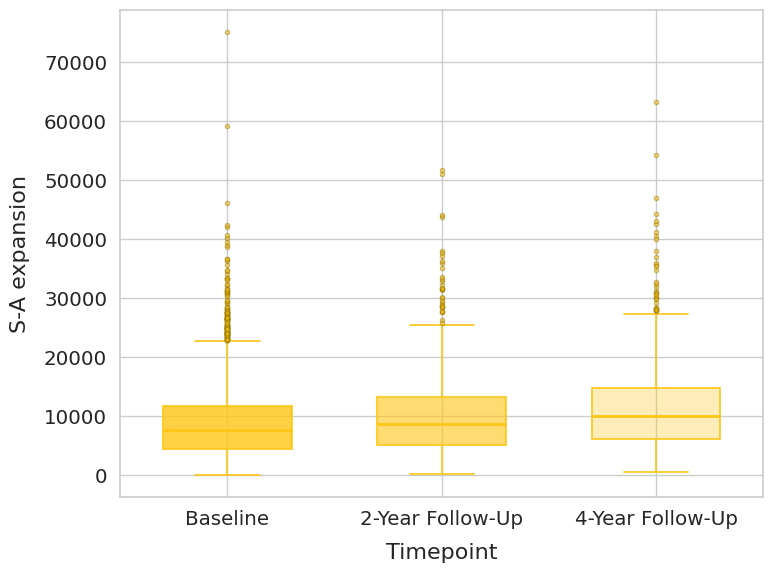

In [53]:
from matplotlib.patches import Patch
import matplotlib.colors as mcolors

timepoints = ["Baseline", "2-Year Follow-Up", "4-Year Follow-Up"]

alpha_map = {"Baseline": 0.8, "2-Year Follow-Up": 0.6, "4-Year Follow-Up": 0.3}
color_base = 'xkcd:golden yellow'


data = [
    SA_expansion_node_baseline,
    SA_expansion_node_fu2y,
    SA_expansion_node_fu4y
]

# --- Style setup (match your other figures) ---
sns.set_theme(style="whitegrid", font="DejaVu Sans", font_scale=1.3)
plt.rcParams["axes.linewidth"] = 1.2
plt.rcParams["boxplot.medianprops.linewidth"] = 2

# --- Create figure ---
plt.figure(figsize=(8, 7))

# Convert data into long-format DataFrame for Seaborn
df = pd.DataFrame({
    "Dispersion": np.concatenate(data),
    "Timepoint": np.repeat(timepoints, [len(d) for d in data])
})

# --- Style setup (consistent with your manuscript) ---
sns.set_theme(style="whitegrid", font="DejaVu Sans", font_scale=1.3)
plt.rcParams["axes.linewidth"] = 1.2
plt.rcParams["boxplot.medianprops.linewidth"] = 2


# --- Create figure and axes ---
fig, ax = plt.subplots(figsize=(8, 6))


# --- Function to draw boxplots with color and alpha ---
def draw_boxplots(ax, data):
    for i, tp in enumerate(timepoints):
        rgba = mcolors.to_rgba(color_base, alpha=alpha_map[tp])
        bp = ax.boxplot(
            data[i],
            positions=[i],
            widths=0.6,
            patch_artist=True,
            boxprops=dict(facecolor=rgba, color=color_base, linewidth=1.2),
            medianprops=dict(color=color_base, linewidth=2),
            whiskerprops=dict(color=color_base, linewidth=1.2),
            capprops=dict(color=color_base, linewidth=1.2),
            flierprops=dict(marker='o', markersize=3, alpha=0.5, markerfacecolor=color_base, markeredgecolor='xkcd:yellowish brown')
        )


# --- Draw boxplots ---
draw_boxplots(ax, data)

# --- Axis labels ---
ax.set_xticks(np.arange(len(timepoints)))
ax.set_xticklabels(timepoints)
ax.set_xlabel("Timepoint", fontsize=16, labelpad=10)
ax.set_ylabel("S-A expansion", fontsize=16, labelpad=10)
ax.legend(loc='upper right', frameon=False)


#sns.despine(trim=True)
plt.tight_layout()

# --- Save or show ---
#plt.show()
#plt.savefig(resdir + "supplementary/SA_expansion_node/figures/boxplot_SA_expansion_node.svg", format="svg", bbox_inches="tight", dpi=300)


### Removing outliers

#### Identifying outliers (using the interquartile range rule), i.e., 
- lower bound =  Q1 - 1.5 * IQR 
- upper bound = Q3 + 1.5 * IQR

In [55]:
### Identifying outliers per timepoint (as shown in boxplot)

data = [
    SA_expansion_node_baseline,
    SA_expansion_node_fu2y,
    SA_expansion_node_fu4y
]

timepoints = ["Baseline", "2-Year Follow-Up", "4-Year Follow-Up"]

for i in range(len(data)):

    print(f"Timepoint: {timepoints[i]}")
    
    
    # --- Compute quartiles and IQR ---
    Q1 = np.percentile(data[i], 25)
    Q3 = np.percentile(data[i], 75)
    IQR = Q3 - Q1
    
    # --- Define outlier bounds (Tukey 1.5×IQR rule) ---
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # --- Identify outliers ---
    outlier_mask = (data[i] < lower_bound) | (data[i] > upper_bound)
    outliers = data[i][outlier_mask]
    
    # --- Optional: view indices of outliers ---
    outlier_indices = np.where(outlier_mask)[0]
    
    print(f"Q1 = {Q1:.3f}, Q3 = {Q3:.3f}, IQR = {IQR:.3f}")
    print(f"Lower bound = {lower_bound:.3f}, Upper bound = {upper_bound:.3f}")
    print(f"Number of outliers = {outliers.size}")
    #print("Outlier values:", outliers)
    #print("Outlier indices:", outlier_indices)
    print("")


Timepoint: Baseline
Q1 = 4487.952, Q3 = 11825.869, IQR = 7337.917
Lower bound = -6518.924, Upper bound = 22832.745
Number of outliers = 151

Timepoint: 2-Year Follow-Up
Q1 = 5203.152, Q3 = 13332.846, IQR = 8129.694
Lower bound = -6991.389, Upper bound = 25527.387
Number of outliers = 32

Timepoint: 4-Year Follow-Up
Q1 = 6124.491, Q3 = 14788.872, IQR = 8664.381
Lower bound = -6872.081, Upper bound = 27785.444
Number of outliers = 34



In [56]:
### Identifying outliers across timepoints <- ** USE THIS **

# concatenate arrays across timepoints
SA_expansion_node_all = np.concatenate([SA_expansion_node_baseline, SA_expansion_node_fu2y, SA_expansion_node_fu4y])


# --- Compute quartiles and IQR across all timepoints ---
Q1 = np.percentile(SA_expansion_node_all, 25)
Q3 = np.percentile(SA_expansion_node_all, 75)
IQR = Q3 - Q1

# --- Define outlier bounds (Tukey 1.5×IQR rule) ---
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


# --- Identify outliers -> within each timpoint ---

# Baseline
outlier_mask_baseline_node = (SA_expansion_node_baseline < lower_bound) | (SA_expansion_node_baseline > upper_bound)
outliers_baseline_node = SA_expansion_node_baseline[outlier_mask_baseline_node]

# Fu2y
outlier_mask_fu2y_node = (SA_expansion_node_fu2y < lower_bound) | (SA_expansion_node_fu2y > upper_bound)
outliers_fu2y_node = SA_expansion_node_fu2y[outlier_mask_fu2y_node]

# Fu4y
outlier_mask_fu4y_node = (SA_expansion_node_fu4y < lower_bound) | (SA_expansion_node_fu4y > upper_bound)
outliers_fu4y_node = SA_expansion_node_fu4y[outlier_mask_fu4y_node]


# --- Indices of outliers (by timpoint)---
outlier_indices_baseline_node = np.where(outlier_mask_baseline_node)[0]
outlier_indices_fu2y_node = np.where(outlier_mask_fu2y_node)[0]
outlier_indices_fu4y_node = np.where(outlier_mask_fu4y_node)[0]


# --- Delete outliers by index (by timpeoint) for all relevant metrics ---

# S-A axis expansion metric
SA_expansion_node_baseline_rm_outliers = np.delete(SA_expansion_node_baseline, outlier_indices_baseline_node)
SA_expansion_node_fu2y_rm_outliers = np.delete(SA_expansion_node_fu2y, outlier_indices_fu2y_node)
SA_expansion_node_fu4y_rm_outliers = np.delete(SA_expansion_node_fu4y, outlier_indices_fu4y_node)

# sub IDs
sub_ID_baseline_rm_outliers_suppl_SA_exp_node = np.delete(sub_ID_baseline, outlier_indices_baseline_node)
sub_ID_fu2y_rm_outliers_suppl_SA_exp_node = np.delete(sub_ID_fu2y, outlier_indices_fu2y_node)
sub_ID_fu4y_rm_outliers_suppl_SA_exp_node = np.delete(sub_ID_fu4y, outlier_indices_fu4y_node)

# demographics dataframe -> for later analyses
abcd_demo_baseline_clean_rm_outliers_suppl_SA_exp_node = abcd_demo_baseline_clean.drop(outlier_indices_baseline_node, axis=0).reset_index(drop=True)  # really important to reset index everytime you drop, otherwise dropping via index != dropping via rows for later steps
abcd_demo_fu2y_clean_rm_outliers_suppl_SA_exp_node = abcd_demo_fu2y_clean.drop(outlier_indices_fu2y_node, axis=0).reset_index(drop=True)  # really important to reset index everytime you drop, otherwise dropping via index != dropping via rows for later steps
abcd_demo_fu4y_clean_rm_outliers_suppl_SA_exp_node = abcd_demo_fu4y_clean.drop(outlier_indices_fu4y_node, axis=0).reset_index(drop=True)  # really important to reset index everytime you drop, otherwise dropping via index != dropping via rows for later steps

# rcoef -> for later analyses
list_SA_axis_corr_to_ref_baseline_rm_outliers_suppl_SA_exp_node = np.delete(list_SA_axis_corr_to_ref_baseline, outlier_indices_baseline_node)
list_SA_axis_corr_to_ref_fu2y_rm_outliers_suppl_SA_exp_node = np.delete(list_SA_axis_corr_to_ref_fu2y, outlier_indices_fu2y_node) 
list_SA_axis_corr_to_ref_fu4y_rm_outliers_suppl_SA_exp_node = np.delete(list_SA_axis_corr_to_ref_fu4y, outlier_indices_fu4y_node)

# gradflip -> for later analyses
list_SA_axis_grad_num_baseline_rm_outliers_suppl_SA_exp_node = np.delete(list_SA_axis_grad_num_baseline, outlier_indices_baseline_node)
list_SA_axis_grad_num_fu2y_rm_outliers_suppl_SA_exp_node = np.delete(list_SA_axis_grad_num_fu2y, outlier_indices_fu2y_node)
list_SA_axis_grad_num_fu4y_rm_outliers_suppl_SA_exp_node = np.delete(list_SA_axis_grad_num_fu4y, outlier_indices_fu4y_node)


print("Definition of outliers across timepoints according to:")
print(f"Q1 = {Q1:.3f}, Q3 = {Q3:.3f}, IQR = {IQR:.3f}")
print(f"Lower bound = {lower_bound:.3f}, Upper bound = {upper_bound:.3f}")
print(f"Number of outliers removed across timepoints = {outliers_baseline_node.size + outliers_fu2y_node.size + outliers_fu4y_node.size}")
#print("Outlier values:", outliers)
#print("Outlier indices:", outlier_indices)


Definition of outliers across timepoints according to:
Q1 = 4858.992, Q3 = 12733.702, IQR = 7874.710
Lower bound = -6953.074, Upper bound = 24545.767
Number of outliers removed across timepoints = 201


<Figure size 800x700 with 0 Axes>

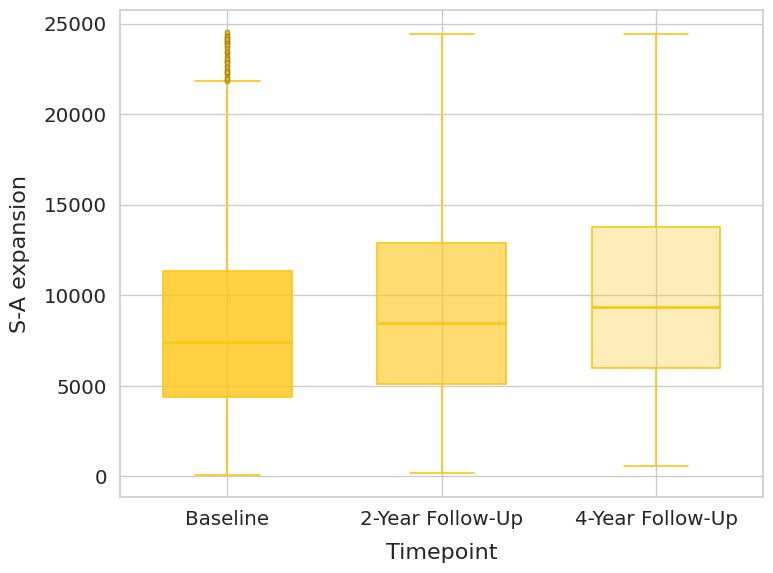

In [58]:
from matplotlib.patches import Patch
import matplotlib.colors as mcolors

timepoints = ["Baseline", "2-Year Follow-Up", "4-Year Follow-Up"]

alpha_map = {"Baseline": 0.8, "2-Year Follow-Up": 0.6, "4-Year Follow-Up": 0.3}
color_base = 'xkcd:golden yellow'


data = [
    SA_expansion_node_baseline_rm_outliers,
    SA_expansion_node_fu2y_rm_outliers,
    SA_expansion_node_fu4y_rm_outliers
]


# --- Style setup (match your other figures) ---
sns.set_theme(style="whitegrid", font="DejaVu Sans", font_scale=1.3)
plt.rcParams["axes.linewidth"] = 1.2
plt.rcParams["boxplot.medianprops.linewidth"] = 2

# --- Create figure ---
plt.figure(figsize=(8, 7))

# Convert data into long-format DataFrame for Seaborn
df = pd.DataFrame({
    "Dispersion": np.concatenate(data),
    "Timepoint": np.repeat(timepoints, [len(d) for d in data])
})

# --- Style setup (consistent with your manuscript) ---
sns.set_theme(style="whitegrid", font="DejaVu Sans", font_scale=1.3)
plt.rcParams["axes.linewidth"] = 1.2
plt.rcParams["boxplot.medianprops.linewidth"] = 2


# --- Create figure and axes ---
fig, ax = plt.subplots(figsize=(8, 6))


# --- Function to draw boxplots with color and alpha ---
def draw_boxplots(ax, data):
    for i, tp in enumerate(timepoints):
        rgba = mcolors.to_rgba(color_base, alpha=alpha_map[tp])
        bp = ax.boxplot(
            data[i],
            positions=[i],
            widths=0.6,
            patch_artist=True,
            boxprops=dict(facecolor=rgba, color=color_base, linewidth=1.2),
            medianprops=dict(color=color_base, linewidth=2),
            whiskerprops=dict(color=color_base, linewidth=1.2),
            capprops=dict(color=color_base, linewidth=1.2),
            flierprops=dict(marker='o', markersize=3, alpha=0.5, markerfacecolor=color_base, markeredgecolor='xkcd:yellowish brown')
            #,showfliers=False ## to remove outliers
        )
        


# --- Draw boxplots ---
draw_boxplots(ax, data)

# --- Axis labels ---
ax.set_xticks(np.arange(len(timepoints)))
ax.set_xticklabels(timepoints)
ax.set_xlabel("Timepoint", fontsize=16, labelpad=10)
ax.set_ylabel("S-A expansion", fontsize=16, labelpad=10)
ax.legend(loc='upper right', frameon=False)


#sns.despine(trim=True)
plt.tight_layout()

# --- Save or show ---
#plt.show()
plt.savefig(resdir + "supplementary/SA_expansion_node/figures/boxplot_SA_expansion_node_rm_outliers.svg", format="svg", bbox_inches="tight", dpi=300)


##### **Export S-A axis expansion computed at parcel level with outliers removed + corresponding demographics dataframe + corresponding rcoef/gradflip -> for R analyses**

In [57]:
# Safety check that sub ID list and demographics subjects are identical (order and elements) - this was done in the cleaning step normally
np.array_equal(np.array(sub_ID_baseline_rm_outliers_suppl_SA_exp_node), np.array(abcd_demo_baseline_clean_rm_outliers_suppl_SA_exp_node.src_subject_id_fmt))

True

In [58]:
# Safety check that sub ID list and demographics subjects are identical (order and elements) - this was done in the cleaning step normally
np.array_equal(np.array(sub_ID_fu2y_rm_outliers_suppl_SA_exp_node), np.array(abcd_demo_fu2y_clean_rm_outliers_suppl_SA_exp_node.src_subject_id_fmt))

True

In [59]:
# Safety check that sub ID list and demographics subjects are identical (order and elements) - this was done in the cleaning step normally
np.array_equal(np.array(sub_ID_fu4y_rm_outliers_suppl_SA_exp_node), np.array(abcd_demo_fu4y_clean_rm_outliers_suppl_SA_exp_node.src_subject_id_fmt))

True

In [60]:
### export dispersion metrics (+ demographics + rcoef/gradflip for R analyses) with removed outliers

## Matfiles

# baseline
mdict = {'SA_expansion_node_baseline': SA_expansion_node_baseline_rm_outliers, 'list_SA_axis_corr_to_ref_baseline': list_SA_axis_corr_to_ref_baseline_rm_outliers_suppl_SA_exp_node, 
         'list_SA_axis_grad_num_baseline': list_SA_axis_grad_num_baseline_rm_outliers_suppl_SA_exp_node, 'sub_ID_baseline': sub_ID_baseline_rm_outliers_suppl_SA_exp_node}

scipy.io.savemat(datadir_local+'SA_expansion_metrics_baseline_rm_outliers_suppl_SA_exp_node.mat', mdict)


# fu2y
mdict = {'SA_expansion_node_fu2y': SA_expansion_node_fu2y_rm_outliers, 'list_SA_axis_corr_to_ref_fu2y': list_SA_axis_corr_to_ref_fu2y_rm_outliers_suppl_SA_exp_node, 
         'list_SA_axis_grad_num_fu2y': list_SA_axis_grad_num_fu2y_rm_outliers_suppl_SA_exp_node, 'sub_ID_fu2y': sub_ID_fu2y_rm_outliers_suppl_SA_exp_node}

scipy.io.savemat(datadir_local+'SA_expansion_metrics_fu2y_rm_outliers_suppl_SA_exp_node.mat', mdict)


# fu4y
mdict = {'SA_expansion_node_fu4y': SA_expansion_node_fu4y_rm_outliers, 'list_SA_axis_corr_to_ref_fu4y': list_SA_axis_corr_to_ref_fu4y_rm_outliers_suppl_SA_exp_node, 
         'list_SA_axis_grad_num_fu4y': list_SA_axis_grad_num_fu4y_rm_outliers_suppl_SA_exp_node, 'sub_ID_fu4y': sub_ID_fu4y_rm_outliers_suppl_SA_exp_node}

scipy.io.savemat(datadir_local+'SA_expansion_metrics_fu4y_rm_outliers_suppl_SA_exp_node.mat', mdict)


## Demographics .csv
abcd_demo_baseline_clean_rm_outliers_suppl_SA_exp_node.to_csv(datadir_local+'abcd_demo_baseline_clean_rm_outliers_suppl_SA_exp_node.csv', header = True, index = False)
abcd_demo_fu2y_clean_rm_outliers_suppl_SA_exp_node.to_csv(datadir_local+'abcd_demo_fu2y_clean_rm_outliers_suppl_SA_exp_node.csv', header = True, index = False)
abcd_demo_fu4y_clean_rm_outliers_suppl_SA_exp_node.to_csv(datadir_local+'abcd_demo_fu4y_clean_rm_outliers_suppl_SA_exp_node.csv', header = True, index = False)
